# SVM deconvolution of cell types

The goal of this notebook is to test the use of SVMs to deconvolve the cell type composition of a bulk mixture.
The input is a matrix containing one line per cell-type specific dmr regions and one column per target cell type:
at (i,j) the value is the mean probit for cell type j averaged on all the reads that overlap a dmr region specific to cell type i.

The specificity is that we will train the SVMs on prediction matrices produced by "pure" mixtures (i.e. containing only one cell type).

The intuition is that the distribution of prediction matrices may be a mixture of gaussians centered on the pure mixtures, and that SVMs with RBF (Radial Basis Function) kernels may have inductive biases that are well suited to learn the deconvolution task.

Short summary of the results:
- all tested methods were worse than UXM by a factor of at least 4 in terms of MSE
- the performance of the regular SVCs is bad, probably because the predicted scores are not well segregated
- the performance of Multiclass LS-SVM is better, but still poor
- the performance of ECOC with Binary LS-SVM + linear layer + softmax is the best among the tested *classification-based* methods, but it is still worse than UXM: on the test split of 1000 unpure mixtures MSE = 0.001869 (vs UXM MSE = 0.000205)
- the performance of the simple Multi-target SVR (Support Vector Regression) is better, even though it has the same inductive bias and training data as the SVCs (Support Vector Classifier). This points that using SVM classification models to infer continuous values is inherently flawed, despite their appropriate inductive biases. SVR MSE = 0.000841 on the test split of 1000 unpure mixtures, which is still worse than UXM.

## 1. Import modules and set constants

In [ ]:
import os
import warnings
from concurrent.futures import ThreadPoolExecutor
from contextlib import contextmanager


import torch
import torch.nn as nn

import numpy as np
import matplotlib.pyplot as plt
import pickle
import pandas as pd
import json
from tqdm.notebook import tqdm

from scipy.linalg import solve
from scipy.spatial.distance import cdist

from sklearn.base import (
    BaseEstimator,
    ClassifierMixin,
    MetaEstimatorMixin,
    RegressorMixin,
    clone,
)
from sklearn.utils.multiclass import unique_labels
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted
from sklearn.svm import SVC, SVR
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression


from methyldl.deconvolution.evaluation import compute_deconvolution_metrics
from methyldl.deconvolution.uxm import (
    load_atlas,
    uxm_deconvolution,
    rearange_uxm_deconvolution_results,
)

We are working on the methylation atlas from [Loyfer et al.](https://www.nature.com/articles/s41586-022-05580-6), with 39 cell types.

In [2]:
# mapping from cell type names to their corresponding labels in the dataset
with open("../App/labels_dict.json", "r") as f:
    labels_dict = json.load(f)
cell_type_to_label = {v: int(k) for k, v in labels_dict.items()}
N_CELL_TYPES = len(cell_type_to_label)

# constants for accessing the mixtures data
PRED_COLUMNS = [f"prediction_{i}_wavg" for i in range(N_CELL_TYPES)]
SPLIT_TO_IDX = {"train": 0, "val": 1, "test": 2}

## 2. Plotting and miscellaneous utilities

In [3]:
@contextmanager
def suppress_many_unique_classes_warning():
    """Suppresses the warning about having many unique classes in the dataset, which occurs when we train SVC with one sample per class."""
    with warnings.catch_warnings():
        warnings.filterwarnings(
            "ignore",
            category=UserWarning,
            message=r"The number of unique classes is greater than 50% of the number of samples*",
        )
        yield

In [4]:
def softmax(logits: np.ndarray, T: float = 1) -> np.ndarray:
    """Compute the softmax of the logits with temperature scaling."""
    is_logits_1d = logits.ndim == 1
    if is_logits_1d:
        logits = logits.reshape(1, -1)
    scaled_logits = logits / T
    exp_scaled = np.exp(scaled_logits - np.max(scaled_logits, axis=1, keepdims=True))
    result = exp_scaled / np.sum(exp_scaled, axis=1, keepdims=True)
    if is_logits_1d:
        result = result.squeeze()
    return result

In [5]:
def plot_heatmap(
    matrix: np.ndarray,
    title: str = "Heatmap",
    color_bar_label: str = "Probability",
    vmin: float | None = None,
    vmax: float | None = None,
):
    """Plot a heatmap of the given matrix with cell type names on the axes."""
    plt.figure(figsize=(10, 8))
    plt.imshow(matrix, cmap="viridis", aspect="auto", vmin=vmin, vmax=vmax)
    plt.colorbar(label=color_bar_label)
    plt.xticks(
        ticks=np.arange(matrix.shape[1]),
        labels=[labels_dict[str(i)] for i in range(matrix.shape[1])],
        rotation=90,
    )
    plt.yticks(
        ticks=np.arange(matrix.shape[0]),
        labels=[labels_dict[str(i)] for i in range(matrix.shape[0])],
    )
    plt.title(title)
    plt.xlabel("Predicted Class")
    plt.ylabel("True Class")
    plt.tight_layout()
    plt.show()

In [6]:
# dichotomic search to find the highest temperature such that at least `min_pass_count`
# true-class probabilities are above `target_confidence`
def find_temperature_for_confidence(
    logits: np.ndarray,
    true_labels: np.ndarray,
    target_confidence: float = 0.99,
    min_pass_count: int = 1,
    atol: float = 1e-3,
    max_iter: int = 20,
) -> float:
    """
    Find the highest temperature T such that at least `min_pass_count` samples have
    P(true_class) >= target_confidence.
    """
    n_samples = len(true_labels)
    if not (1 <= min_pass_count <= n_samples):
        raise ValueError(
            f"min_pass_count must be in [1, {n_samples}], got {min_pass_count}"
        )

    low, high = 1e-3, 100.0
    best_T = low

    for i in range(max_iter):
        mid_T = (low + high) / 2
        probabilities = softmax(logits, T=mid_T)
        true_class_probs = probabilities[np.arange(n_samples), true_labels]
        pass_count = np.count_nonzero(true_class_probs >= target_confidence)

        if pass_count >= min_pass_count:
            best_T = mid_T
            low = mid_T
        else:
            high = mid_T

        if high - low < atol:
            print(
                f"Dichotomic search converged within tolerance {atol} "
                f"(final range: [{low}, {high}], iter={i})"
            )
            return best_T

    print(
        f"Warning: dichotomic search did not converge within tolerance {atol} "
        f"(final range: [{low}, {high}], iter={max_iter - 1})"
    )
    return best_T

In [7]:
def plot_mixtures_pred_vs_true(
    ground_truth_mixture: np.ndarray,
    predicted_mixtures: list[np.ndarray],
    predicted_mixture_labels: list[str],
    width: float = 0.2,
    title: str = "Predicted Mixtures vs Ground Truth Mixture",
):
    """
    Plot the predicted mixtures against the ground truth mixture for a single sample.
    The function creates a bar plot where the x axis represents the cell types and the y axis represents the mixture proportions.
    Each predicted mixture is plotted as a separate bar. The ground truth mixture is plotted as red dots for each cell type.

    Args:
        ground_truth_mixture: A 1D array of shape (n_cell_types,) representing the true mixture proportions.
        predicted_mixtures: A list of 1D arrays, each of shape (n_cell_types,), representing the predicted mixture proportions from different models.
        predicted_mixture_labels: A list of strings representing the labels for each predicted mixture (e.g., model names).
    """
    assert len(predicted_mixtures) == len(
        predicted_mixture_labels
    ), "Number of predicted mixtures must match number of labels"
    assert all(
        pred.shape == ground_truth_mixture.shape for pred in predicted_mixtures
    ), "All predicted mixtures must have the same shape as the ground truth mixture"
    plt.figure(figsize=(8, 6))
    n_cell_types = len(ground_truth_mixture)
    n_predicted_mixtures = len(predicted_mixtures)
    x = np.arange(n_cell_types)  # start of the the label locations
    x_center = (
        x + width * (n_predicted_mixtures - 1) / 2
    )  # middle of the group of bars for each cell type

    # Plot the ground truth mixture as red dots
    plt.scatter(
        x_center, ground_truth_mixture, color="red", zorder=-1, label="Ground Truth"
    )

    # Plot each predicted mixture as a bar
    for i, (predicted_mixture, label) in enumerate(
        zip(predicted_mixtures, predicted_mixture_labels)
    ):
        plt.bar(x + i * width, predicted_mixture, width, label=label)

    # plot the cell types names on the x axis, rotated by 90 degrees
    plt.xticks(x_center, cell_type_to_label.keys(), rotation=90)
    plt.ylabel("Mixture Proportions")
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

## 3. Data Loading

### 3.1. Pure mixtures

The file that we load in this section contains the input and output data related to the pure mixtures.

For every cell_type i:

- file[i][0] - Ground Truth proportions.
- file[i][1][k] - Pandas dataframes with aggregated predictions (k in 0,1,2 means train, validation and test datasets respectfully)
- file[i][2][k] - UXM input matrices and deconvolution results (k in 0,1,2 means train, validation and test datasets respectfully)

In [8]:
with open("../Data/mixtures/soft_labels_pure_ios.pkl", "rb") as f:
    soft_labels_pure_ios = pickle.load(f)

In [9]:
# functions to extract data from the loaded pickle file containing the pure mixtures and their corresponding predictions and ground truth labels
def get_pure_prediction_matrix(
    cell_type_name: int | str, split_name: str = "train"
) -> np.ndarray:
    if isinstance(cell_type_name, str):
        cell_type_label = cell_type_to_label[cell_type_name]
    else:
        cell_type_label = cell_type_name
    split_idx = SPLIT_TO_IDX[split_name]
    return soft_labels_pure_ios[cell_type_label][1][split_idx][PRED_COLUMNS].to_numpy()


def get_pure_uxm_results(
    cell_type_name: int | str, split_name: str = "train"
) -> pd.DataFrame:
    if isinstance(cell_type_name, str):
        cell_type_label = cell_type_to_label[cell_type_name]
    else:
        cell_type_label = cell_type_name
    split_idx = SPLIT_TO_IDX[split_name]
    return np.array(soft_labels_pure_ios[cell_type_label][2][split_idx][3])


def get_pure_ground_truth_mixture(cell_type_name: int | str) -> np.ndarray:
    if isinstance(cell_type_name, str):
        cell_type_label = cell_type_to_label[cell_type_name]
    else:
        cell_type_label = cell_type_name
    return np.array(soft_labels_pure_ios[cell_type_label][0])

### 3.2. Unpure mixtures

The file that we load in this section contains the input and output data related to the 1000 unpure mixtures.

The layout of the pkl is the same as for the pure mixtures, except that:

- the list contains 1000 tuples instead of 39
- the Ground Truth proportions are no longer one-hot vectors but rather vectors with 39 entries that sum to 1.
- the deconvolution *results* for UXM are not given and thus must be computed (the UXM *inputs* are given)

In [10]:
with open(
    "../Data/mixtures/ios_deconvolution_data_hg38_grouped_dmrs_uxm_alligned_1000.pkl",
    "rb",
) as f:
    unpure_mixtures_data = pickle.load(f)

In [11]:
# computing uxm deconvolution results for the unpure mixtures (if not already computed and saved in a pickle file)
file_uxm_unpure_results = (
    "../Data/mixtures/uxm_deconvolution_results_unpure_mixtures.pkl"
)
if os.path.exists(file_uxm_unpure_results):
    with open(file_uxm_unpure_results, "rb") as f:
        uxm_unpure_results = pickle.load(f)
    print(
        f"Loaded precomputed UxM deconvolution results for unpure mixtures from {file_uxm_unpure_results}"
    )
else:
    uxm_unpure_results = []
    uxm_atlas, uxm_ref_cells = load_atlas(
        "../Data/UXM_atlas/Atlas.U25.l4.hg38.full.tsv"
    )
    for mixture_idx in tqdm(range(len(unpure_mixtures_data))):
        uxm_unpure_results.append([])
        for split_idx in range(3):
            sf, counts = unpure_mixtures_data[mixture_idx][2][split_idx][:2]
            uxm_raw = uxm_deconvolution(
                atlas=uxm_atlas,
                ref_cells=uxm_ref_cells,
                sf=sf,
                counts=counts,
                sample_names=["pseudo_balk_sample"],
            )[0]
            uxm_aligned = np.array(
                rearange_uxm_deconvolution_results(
                    labels_dict_reversed=cell_type_to_label,
                    uxm_proportions=uxm_raw,
                    ref_cells=uxm_ref_cells,
                )
            )
            uxm_unpure_results[-1].append(uxm_aligned)
    with open(file_uxm_unpure_results, "wb") as f:
        pickle.dump(uxm_unpure_results, f)
    print(
        f"Saved UxM deconvolution results for unpure mixtures to {file_uxm_unpure_results}"
    )

Loaded precomputed UxM deconvolution results for unpure mixtures from ../Data/mixtures/uxm_deconvolution_results_unpure_mixtures.pkl


In [12]:
# functions to extract the unpure mixtures data from the loaded pickle file, which contains the predictions and ground truth labels for the unpure mixtures
def get_unpure_prediction_matrix(
    mixture_idx: int, split_name: str = "train"
) -> np.ndarray:
    split_idx = SPLIT_TO_IDX[split_name]
    return unpure_mixtures_data[mixture_idx][1][split_idx][PRED_COLUMNS].to_numpy()


def get_unpure_uxm_results(mixture_idx: int, split_name: str = "train") -> pd.DataFrame:
    split_idx = SPLIT_TO_IDX[split_name]
    return np.array(uxm_unpure_results[mixture_idx][split_idx])


def get_unpure_ground_truth_mixture(mixture_idx: int) -> np.ndarray:
    return np.array(unpure_mixtures_data[mixture_idx][0])

### 3.3 Mixtures with feature selection

In this section, we load a file with 100000 mixtures with feature selection. The features were selected based on whether feature.max()/feature.mean() > 1.1 where the statistics are computed on all mixtures in the union of the train and validation and test sets (yes, this is data leakage).

In [13]:
filename = "features_1.1_cutoff.npz"
filepath = f"../Data/mixtures/{filename}"
if os.path.exists(filepath):
    print(f"Loading feature-selected raw data from {filepath}")
    feature_selected_raw_data = np.load(filepath, allow_pickle=True)
else:
    print(
        f"Feature-selected raw data file not found at {filepath}. Please make sure the file exists."
    )

Loading feature-selected raw data from ../Data/mixtures/features_1.1_cutoff.npz


In [14]:
# find the indexes of the pure mixtures
pure_mixtures_indexes = []
for cell_type_idx in tqdm(range(N_CELL_TYPES)):
    for i, gr_proportions in enumerate(feature_selected_raw_data["proportions"]):
        if gr_proportions[cell_type_idx] == 1.0:
            pure_mixtures_indexes.append(i)
            break
    if i == len(feature_selected_raw_data["proportions"]) - 1:
        print(
            f"Warning: no pure mixture found for cell type {cell_type_idx} ({labels_dict[str(cell_type_idx)]})"
        )

  0%|          | 0/39 [00:00<?, ?it/s]

## 4. Data Preprocessing

Preprocessing of the data (essentially flattening the matrices)

In [16]:
# Preparation of the train, validation and test sets for the pure mixtures
def prepare_pure_dataset(split_name: str = "train"):
    X = np.array(
        [
            get_pure_prediction_matrix(cell_type_idx, split_name)
            for cell_type_idx in range(N_CELL_TYPES)
        ]
    )
    y = np.array(
        [
            get_pure_ground_truth_mixture(cell_type_idx)
            for cell_type_idx in range(N_CELL_TYPES)
        ]
    )
    return X, y


# keep the original shape of the data
X_pure_train, y_pure_train = prepare_pure_dataset("train")
X_pure_val, y_pure_val = prepare_pure_dataset("val")
X_pure_test, y_pure_test = prepare_pure_dataset("test")

y_pure_by_split = {
    "train": y_pure_train,
    "val": y_pure_val,
    "test": y_pure_test,
}

# transform the targets to the cell type with the highest proportion in the ground truth mixture
y_pure_train_labels = np.argmax(y_pure_train, axis=1)
y_pure_val_labels = np.argmax(y_pure_val, axis=1)
y_pure_test_labels = np.argmax(y_pure_test, axis=1)

# flatten the matrices
X_pure_train_full = X_pure_train.reshape(X_pure_train.shape[0], -1)
X_pure_val_full = X_pure_val.reshape(X_pure_val.shape[0], -1)
X_pure_test_full = X_pure_test.reshape(X_pure_test.shape[0], -1)

X_pure_full_by_split = {
    "train": X_pure_train_full,
    "val": X_pure_val_full,
    "test": X_pure_test_full,
}

# keep only the diagonal elements of the prediction matrices
X_pure_train_diag = X_pure_train[:, np.arange(N_CELL_TYPES), np.arange(N_CELL_TYPES)]
X_pure_val_diag = X_pure_val[:, np.arange(N_CELL_TYPES), np.arange(N_CELL_TYPES)]
X_pure_test_diag = X_pure_test[:, np.arange(N_CELL_TYPES), np.arange(N_CELL_TYPES)]

In [17]:
# Preparation of the train, validation and test sets for the unpure mixtures
def prepare_unpure_dataset(split_name: str = "train"):
    X = np.array(
        [
            get_unpure_prediction_matrix(mixture_idx, split_name)
            for mixture_idx in range(len(unpure_mixtures_data))
        ]
    )

    y = np.array(
        [
            get_unpure_ground_truth_mixture(mixture_idx)
            for mixture_idx in range(len(unpure_mixtures_data))
        ]
    )
    return X, y


# keep the original shape of the data
X_unpure_train, y_unpure_train = prepare_unpure_dataset("train")
X_unpure_val, y_unpure_val = prepare_unpure_dataset("val")
X_unpure_test, y_unpure_test = prepare_unpure_dataset("test")


y_unpure_by_split = {
    "train": y_unpure_train,
    "val": y_unpure_val,
    "test": y_unpure_test,
}

# transform the targets to the cell type with the highest proportion in the ground truth mixture
y_unpure_train_labels = np.argmax(y_unpure_train, axis=1)
y_unpure_val_labels = np.argmax(y_unpure_val, axis=1)
y_unpure_test_labels = np.argmax(y_unpure_test, axis=1)

# flattens the matrices
X_unpure_train_full = X_unpure_train.reshape(X_unpure_train.shape[0], -1)
X_unpure_val_full = X_unpure_val.reshape(X_unpure_val.shape[0], -1)
X_unpure_test_full = X_unpure_test.reshape(X_unpure_test.shape[0], -1)

X_unpure_full_by_split = {
    "train": X_unpure_train_full,
    "val": X_unpure_val_full,
    "test": X_unpure_test_full,
}

In [18]:
# Preparation of the train, validation and test sets for the mixtures with feature selection
y_pure_ft_selected = np.array(
    [
        get_pure_ground_truth_mixture(cell_type_idx)
        for cell_type_idx in range(N_CELL_TYPES)
    ]
)

y_ft_selected = feature_selected_raw_data["proportions"]

X_pure_ft_selected_by_split = {
    "train": feature_selected_raw_data["features_train"][pure_mixtures_indexes],
    "val": feature_selected_raw_data["features_valid"][pure_mixtures_indexes],
    "test": feature_selected_raw_data["features_test"][pure_mixtures_indexes],
}

X_ft_selected_by_split = {
    "train": feature_selected_raw_data["features_train"],
    "val": feature_selected_raw_data["features_valid"],
    "test": feature_selected_raw_data["features_test"],
}

## 5. Modelling with classification models

In this section, we try to perform deconvolution with SVMs that are originally designed to perform classification tasks.

### 5.0 Model definitions

The model definitions are given separately from the experiments because some models are used in multiple experiments, and you might want to launch only some of the experiments.

In [19]:
class MulticlassLSSVM:
    def __init__(self, gamma=1.0, sigma=1.0, kernel="rbf"):
        """
        Initializes the LS-SVM.
        gamma: Regularization parameter (gamma in the paper).
        sigma: RBF kernel width parameter. Only used when kernel='rbf'.
        kernel: Kernel type to use. Supported values are 'linear' and 'rbf'.
        """
        assert kernel in ["linear", "rbf"], "kernel must be either 'linear' or 'rbf'"
        self.gamma = gamma
        self.sigma = sigma
        self.kernel = kernel
        self.models = (
            []
        )  # Will store (b_i, alpha_i, X_pure_train, y_pure_train_i) for each class

    def _compute_kernel(self, X1, X2):
        """
        Computes the kernel matrix used in the dual LS-SVM system.
        Supported kernels:
        - linear: K(x_k, x_l) = x_k^T x_l
        - rbf: K(x_k, x_l) = exp(-||x_k - x_l||_2^2 / sigma^2)
        """
        if self.kernel == "linear":
            return X1 @ X2.T
        if self.kernel == "rbf":
            dists_sq = cdist(X1, X2, "sqeuclidean")
            return np.exp(-dists_sq / (self.sigma**2))
        raise ValueError(
            f"Unsupported kernel '{self.kernel}'. Expected 'linear' or 'rbf'."
        )

    def fit(self, X, Y):
        """
        Trains the Multiclass LS-SVM.
        X: Training data of shape (N, features)
        Y: One-hot encoded (or multi-output encoded) labels of shape (N, m)
           where m is the number of classes/outputs. Values should be +1 or -1.
        """
        if Y.ndim != 2:
            raise ValueError(
                f"Y must be a 2D array of shape (n_samples, n_classes), got shape {Y.shape}"
            )
        if self.kernel == "rbf" and self.sigma <= 0:
            raise ValueError(
                "sigma must be strictly positive when using the RBF kernel"
            )

        N, m = Y.shape
        self.models = []

        # Calculate the kernel matrix for the training data
        Psi = self._compute_kernel(X, X)

        # Because Y_M and Omega_M are block diagonal, we can solve
        # the linear system independently for each of the m outputs.
        for i in range(m):
            y_i = Y[:, i].reshape(-1, 1)

            # Omega_kl = y_k * y_l * Psi(x_k, x_l) + I / gamma
            # Calculate y_k * y_l matrix
            y_y_T = np.dot(y_i, y_i.T)

            # Element-wise multiplication for Omega + regularization term
            Omega = y_y_T * Psi + np.eye(N) / self.gamma

            # Construct the left-hand side matrix A: [[0, y_T], [y, Omega]]
            A = np.zeros((N + 1, N + 1))
            A[0, 1:] = y_i.T
            A[1:, 0] = y_i.flatten()
            A[1:, 1:] = Omega

            # Construct the right-hand side vector B: [0, 1, ..., 1]^T
            B = np.ones((N + 1, 1))
            B[0, 0] = 0

            # Solve the linear system A * [b; alpha] = B
            solution = solve(A, B)

            # Extract b and alpha
            b_i = solution[0, 0]
            alpha_i = solution[1:, 0].reshape(-1, 1)

            # Store the parameters for this output class
            self.models.append((b_i, alpha_i, X, y_i))

        return self

    def predict(self, X_pure_test):
        """
        Predicts classes for new data points.
        Returns the raw decision values. You can take np.argmax() of the
        output to get the final class prediction if using a 1-vs-all encoding.
        """
        num_test = X_pure_test.shape[0]
        m = len(self.models)
        predictions = np.zeros((num_test, m))

        for i in range(m):
            b_i, alpha_i, X_pure_train, y_i = self.models[i]

            # Calculate kernel between test data and training data
            Psi_test = self._compute_kernel(X_pure_test, X_pure_train)

            # Decision function: sum(alpha_k * y_k * Psi(x, x_k)) + b
            # We compute this in a vectorized manner for all test points
            weighted_Psi = Psi_test * (alpha_i * y_i).T
            predictions[:, i] = np.sum(weighted_Psi, axis=1) + b_i

        return predictions

In [20]:
class BinaryLSSVM(BaseEstimator, ClassifierMixin):
    """Binary Least-Squares SVM compatible with sklearn meta-estimators."""

    def __init__(self, gamma=1.0, sigma=1.0, kernel="rbf"):
        self.gamma = gamma
        self.sigma = sigma
        self.kernel = kernel

    def _validate_hyperparameters(self):
        if self.gamma <= 0:
            raise ValueError("gamma must be strictly positive")
        if self.kernel not in {"linear", "rbf"}:
            raise ValueError("kernel must be either 'linear' or 'rbf'")
        if self.kernel == "rbf" and self.sigma <= 0:
            raise ValueError(
                "sigma must be strictly positive when using the RBF kernel"
            )

    def _compute_kernel(self, X1, X2):
        if self.kernel == "linear":
            return X1 @ X2.T
        dists_sq = cdist(X1, X2, "sqeuclidean")
        return np.exp(-dists_sq / (self.sigma**2))

    def fit(self, X, y):
        X, y = check_X_y(X, y)
        self._validate_hyperparameters()

        self.classes_ = unique_labels(y)
        if self.classes_.shape[0] != 2:
            raise ValueError(
                f"BinaryLSSVM expects exactly 2 classes, got {self.classes_.shape[0]}"
            )

        y_signed = np.where(y == self.classes_[0], -1.0, 1.0).reshape(-1, 1)
        n_samples = X.shape[0]

        kernel_matrix = self._compute_kernel(X, X)
        omega = (y_signed @ y_signed.T) * kernel_matrix + np.eye(n_samples) / self.gamma

        system_matrix = np.zeros((n_samples + 1, n_samples + 1), dtype=float)
        system_matrix[0, 1:] = y_signed.ravel()
        system_matrix[1:, 0] = y_signed.ravel()
        system_matrix[1:, 1:] = omega

        rhs = np.ones(n_samples + 1, dtype=float)
        rhs[0] = 0.0

        try:
            solution = solve(system_matrix, rhs, assume_a="sym")
        except np.linalg.LinAlgError:
            solution = np.linalg.lstsq(system_matrix, rhs, rcond=None)[0]

        self.intercept_ = float(solution[0])
        self.alpha_ = solution[1:].reshape(-1, 1)
        self.X_fit_ = X
        self.y_fit_signed_ = y_signed
        self.dual_coef_ = self.alpha_ * self.y_fit_signed_
        self.n_features_in_ = X.shape[1]
        return self

    def decision_function(self, X):
        check_is_fitted(
            self, ["X_fit_", "y_fit_signed_", "alpha_", "intercept_", "classes_"]
        )
        X = check_array(X)
        kernel_matrix = self._compute_kernel(X, self.X_fit_)
        scores = kernel_matrix @ (self.alpha_ * self.y_fit_signed_)
        return scores.ravel() + self.intercept_

    def predict(self, X):
        scores = self.decision_function(X)
        return np.where(scores >= 0.0, self.classes_[1], self.classes_[0])

In [21]:
class CustomECOC(MetaEstimatorMixin, ClassifierMixin, BaseEstimator):
    """
    ECOC meta-estimator for multiclass problems using binary base estimators.

    Each column of the code matrix defines one binary problem.
    """

    def __init__(
        self,
        base_estimator,
        n_bits,
        n_classes,
        matrix_construction_mode="full_random",
        random_state=42,
        decision_function_workers=1,
        log_reg_max_iter=1000,
        fit_logistic_regression=True,
    ):
        """
        The constructor for the CustomECOC class.
        The logistic regression model based on the decision values of the binary classifiers
        is trained to predict the class probabilities.

        Args:
            base_estimator: The binary classifier to use for each bit. Must implement fit and decision_function.
            n_bits: The number of bits (columns) in the ECOC code matrix.
            n_classes: The number of classes (rows) in the ECOC code matrix.
            matrix_construction_mode: The method to construct the ECOC code matrix. Currently only supports "full_random".
            random_state: Random seed for reproducibility when constructing the code matrix.
            decision_function_workers: Number of worker threads used to collect
                binary decision values. Use 1 to disable parallelism.
            fit_logistic_regression: Whether to fit a logistic regression model on the decision values.
        """
        # perform input validation
        n_bits = int(n_bits)
        decision_function_workers = int(decision_function_workers)
        if n_bits < int(np.ceil(np.log2(n_classes))):
            raise ValueError(
                f"n_bits={n_bits} is too small for n_classes={n_classes}; must be at least {int(np.ceil(np.log2(n_classes)))}"
            )
        if n_classes < 2:
            raise ValueError("n_classes must be at least 2")
        if decision_function_workers < 1:
            raise ValueError("decision_function_workers must be at least 1")
        if not hasattr(base_estimator, "fit"):
            raise TypeError("base_estimator must implement fit")
        if not hasattr(base_estimator, "decision_function"):
            raise TypeError("base_estimator must implement decision_function")

        self.classes_ = np.arange(n_classes)
        self.base_estimator = base_estimator
        self.n_bits = n_bits
        self.n_classes = n_classes
        self.matrix_construction_mode = matrix_construction_mode
        self.random_state = random_state
        self.decision_function_workers = decision_function_workers
        self.fit_logistic_regression = fit_logistic_regression
        self.log_reg_max_iter = log_reg_max_iter

    def construct_code_matrix(self):
        if self.matrix_construction_mode == "full_random":
            return self._construct_full_random_code_matrix(self.n_classes)
        else:
            raise ValueError(
                f"Unknown matrix_construction_mode: {self.matrix_construction_mode}"
            )

    def _construct_full_random_code_matrix(self, n_classes):
        """
        Construct a random ECOC code matrix with the specified number of classes and bits, ensuring that:
        - Each row (class) has a unique code.
        - Each column (bit) is not constant across all classes (i.e., has at least one +1 and one -1).

        This is the recommended way according to the [User guide of sklearn](https://scikit-learn.org/stable/modules/multiclass.html#outputcodeclassifier).
        """
        rng = np.random.default_rng(self.random_state)

        for _ in range(1000):
            code_matrix = rng.choice([-1.0, 1.0], size=(n_classes, self.n_bits))

            if np.unique(code_matrix, axis=0).shape[0] != n_classes:
                continue

            if np.any(np.abs(code_matrix.sum(axis=0)) == n_classes):
                continue

            return code_matrix

        raise RuntimeError(
            "Failed to construct a valid random ECOC code matrix after 1000 attempts"
        )

    def fit(self, X, y):
        """
        Fit the ECOC model according to the given training data.

        Args:
            X: array-like of shape (n_samples, n_features)
                The training input samples.
            y: array-like of shape (n_samples,)
                The target class labels (must be integers from 0 to n_classes-1).
        """
        X, y = check_X_y(X, y)

        assert (
            len(np.unique(y)) <= self.n_classes
        ), f"Number of unique classes in y ({len(np.unique(y))}) exceeds n_classes={self.n_classes}"

        self.code_matrix_ = self.construct_code_matrix()
        self.estimators_ = []

        for bit_idx in range(self.code_matrix_.shape[1]):
            estimator = clone(self.base_estimator)
            y_binary = self.code_matrix_[y, bit_idx]
            estimator.fit(X, y_binary)
            self.estimators_.append(estimator)

        self.n_features_in_ = X.shape[1]

        if self.fit_logistic_regression:
            decision_values = self._collect_decision_values(
                X
            )  # shape (n_samples, n_bits)
            self.calibration_model_ = LogisticRegression(max_iter=self.log_reg_max_iter)
            self.calibration_model_.fit(decision_values, y)

        return self

    @staticmethod
    def _compute_estimator_decision_values(estimator, X):
        bit_scores = np.asarray(estimator.decision_function(X))
        if bit_scores.ndim == 2:
            bit_scores = bit_scores[:, -1]
        return bit_scores.ravel()

    def _collect_decision_values_sequential(self, X):
        """Collect decision values by iterating over estimators sequentially."""
        decision_values = np.empty((X.shape[0], len(self.estimators_)), dtype=float)

        for bit_idx, estimator in enumerate(self.estimators_):
            decision_values[:, bit_idx] = self._compute_estimator_decision_values(
                estimator, X
            )

        return decision_values

    def _collect_decision_values_parallel(self, X):
        """Collect decision values using a fixed number of worker threads."""
        with ThreadPoolExecutor(max_workers=self.decision_function_workers) as executor:
            bit_scores_per_estimator = list(
                executor.map(
                    lambda estimator: self._compute_estimator_decision_values(
                        estimator, X
                    ),
                    self.estimators_,
                )
            )

        return np.column_stack(bit_scores_per_estimator)

    def _collect_decision_values(self, X):
        """
        Collect the decision values from each binary estimator for the input samples.

        Args:
            X: array-like of shape (n_samples, n_features)
                The input samples for which to collect decision values.
        Returns:
            decision_values: array of shape (n_samples, n_bits)
                The collected decision values from each binary estimator.
        """
        X = check_array(X)
        check_is_fitted(self, ["code_matrix_", "estimators_"])

        if self.decision_function_workers == 1 or len(self.estimators_) <= 1:
            return self._collect_decision_values_sequential(X)

        return self._collect_decision_values_parallel(X)

    def decision_function(self, X):
        """
        Compute the decision function for the input samples.
        Performs the aggregation of the decision values of the estimators
        according to the ECOC code matrix and returns a score for each class.

        Args:
            X: array-like of shape (n_samples, n_features)
                The input samples for which to compute the decision function.
        Returns:
            decision_values: array of shape (n_samples, n_classes)
                The computed decision values for each class.
        """
        decision_values = self._collect_decision_values(X)
        return decision_values @ self.code_matrix_.T / self.code_matrix_.shape[1]

    def predict_proba(self, X):
        """Predict class probabilities for the input samples using the
        calibrated logistic regression model on the decision values.

        Args:
            X: array-like of shape (n_samples, n_features)
                The input samples for which to predict probabilities.

        Returns:
            proba: array of shape (n_samples, n_classes)
                The predicted class probabilities for each sample.
        """
        if not self.fit_logistic_regression:
            raise NotImplementedError(
                "predict_proba is not available when fit_logistic_regression=False"
            )

        decision_values = self._collect_decision_values(X)
        proba = self.calibration_model_.predict_proba(decision_values)
        desired_order = np.arange(self.n_classes)
        current_order = self.calibration_model_.classes_
        if not np.array_equal(current_order, desired_order):
            reindex = [
                np.where(current_order == label)[0][0] for label in desired_order
            ]
            proba = proba[:, reindex]
        return proba

    def predict(self, X):
        raise NotImplementedError()

    def code_matrix_to_str(self):
        return "\n".join(
            [
                "".join(["1" if bit == 1 else "0" for bit in row])
                for row in self.code_matrix_
            ]
        )

In [22]:
class ClassifierHead(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, output_dim)

    def forward(self, x):
        return self.linear(x)


class CombinedECOCCalibrationModel:
    def __init__(
        self,
        base_estimator,
        n_bits,
        n_classes,
        matrix_construction_mode="full_random",
        random_state=42,
        decision_function_workers=1,
        device="cuda",
    ):
        super().__init__()
        self.ecoc_model = CustomECOC(
            base_estimator=base_estimator,
            n_bits=n_bits,
            n_classes=n_classes,
            matrix_construction_mode=matrix_construction_mode,
            random_state=random_state,
            decision_function_workers=decision_function_workers,
            fit_logistic_regression=False,
        )

        if device == "cuda" and not torch.cuda.is_available():
            print("CUDA is not available, falling back to CPU")
            device = "cpu"
        self.device = torch.device(device)
        self.calibration_head = ClassifierHead(
            input_dim=n_bits, output_dim=n_classes
        ).to(self.device)

    def fit(
        self,
        X_pure: np.ndarray,
        y_pure: np.ndarray,
        X_unpure: np.ndarray,
        y_unpure: np.ndarray,
        n_epochs=100,
        batch_size=None,
        lr=1e-3,
        return_metrics=True,
    ):
        """
        Args:
            X_pure: array-like of shape (n_pure_samples, n_features)
                The training input samples for the pure mixtures.
            y_pure: array-like of shape (n_pure_samples, n_classes)
                The one-hot encoded target class labels for the pure mixtures.
            X_unpure: array-like of shape (n_unpure_samples, n_features)
                The training input samples for the unpure mixtures.
            y_unpure: array-like of shape (n_unpure_samples, n_classes)
                The mixture proportions (soft labels) for the unpure mixtures.
            n_epochs: int
                The number of epochs to train the calibration head.
            batch_size: int or None
                The batch size to use for training the calibration head. If None, uses the entire dataset as a single batch.
            lr: float
                The learning rate for training the calibration head.
            return_metrics: bool
                Whether to return a dictionary containing training metrics (loss and learning rate per epoch).
        """
        if batch_size is None:
            batch_size = len(X_unpure)

        print("Fitting ECOC model on pure mixtures...", flush=True)
        self.ecoc_model.fit(X_pure, y_pure)
        print("Finished fitting ECOC model on pure mixtures.", flush=True)
        print("Collecting decision values for unpure mixtures...", flush=True)
        decision_values_unpure = self.ecoc_model._collect_decision_values(X_unpure)
        print("Finished collecting decision values for unpure mixtures.", flush=True)
        self.calibration_head.to(self.device)

        X_train_tensor = (
            torch.from_numpy(decision_values_unpure).float().to(self.device)
        )
        y_train_tensor = torch.from_numpy(y_unpure).float().to(self.device)

        dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
        dataloader = torch.utils.data.DataLoader(
            dataset, batch_size=batch_size, shuffle=True
        )

        optimizer = torch.optim.Adam(self.calibration_head.parameters(), lr=lr)
        cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=n_epochs
        )
        criterion = nn.KLDivLoss(reduction="batchmean")

        metrics = {
            "epochs": [],
            "loss": [],
            "learning_rate": [],
        }

        for epoch in tqdm(range(n_epochs)):
            epoch_loss = 0.0
            for batch_X, batch_y in dataloader:
                optimizer.zero_grad()
                logits = self.calibration_head(batch_X)
                log_probs = nn.functional.log_softmax(logits, dim=1)
                loss = criterion(log_probs, batch_y)
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item() * batch_X.size(0)

            cosine_scheduler.step()
            epoch_loss /= len(dataset)

            if return_metrics:
                metrics["epochs"].append(epoch + 1)
                metrics["loss"].append(epoch_loss)
                metrics["learning_rate"].append(optimizer.param_groups[0]["lr"])

        self.calibration_head.eval()

        if return_metrics:
            return metrics

    def predict_proba(self, X):
        """
        Predict class probabilities for the input samples using the combined ECOC decision values and calibration head.

        Args:
            X: array-like of shape (n_samples, n_features)
                The input samples for which to predict probabilities.

        Returns:
            proba: array of shape (n_samples, n_classes)
                The predicted class probabilities for each sample.
        """
        decision_values = self.ecoc_model._collect_decision_values(X)
        decision_values_tensor = (
            torch.from_numpy(decision_values).float().to(self.device)
        )
        with torch.inference_mode():
            logits = self.calibration_head(decision_values_tensor)
            proba = nn.functional.softmax(logits, dim=1).cpu().numpy()
        return proba

### 5.1. SVM classification with probabilities as mixture proportions

In this section, we train SVMs using the sklearn implementation, and we use [the probabilities of the SVMs](https://scikit-learn.org/stable/modules/svm.html#scores-and-probabilities) as mixture proportions.

We try using:

- the full prediction matrices vs only the diagonal (i.e. the predictions on the dmr regions specific to each cell type)
- RBF vs linear kernels

In [ ]:
def full_svm_experiment(kernel="rbf", data_to_use="full"):
    """Full experiment to train an SVC with probabilities as mixture proportions for the deconvolution task"""
    if data_to_use == "full":
        X_pure_train = X_pure_train_full
        X_pure_val = X_pure_val_full
        X_pure_test = X_pure_test_full
    elif data_to_use == "diag":
        X_pure_train = X_pure_train_diag
        X_pure_val = X_pure_val_diag
        X_pure_test = X_pure_test_diag
    else:
        raise ValueError("data_to_use must be either 'full' or 'diag'")

    with suppress_many_unique_classes_warning():
        # training the SVM classifier
        svm = SVC(kernel=kernel, probability=True)
        svm.fit(X_pure_train, y_pure_train_labels)

        # making predictions on the train, validation and test sets
        train_label_predictions = svm.predict(X_pure_train)
        val_label_predictions = svm.predict(X_pure_val)
        test_label_predictions = svm.predict(X_pure_test)

        train_mixture_predictions = svm.predict_proba(X_pure_train)
        val_mixture_predictions = svm.predict_proba(X_pure_val)
        test_mixture_predictions = svm.predict_proba(X_pure_test)

        train_label_pred_from_proba = train_mixture_predictions.argmax(axis=1)
        val_label_pred_from_proba = val_mixture_predictions.argmax(axis=1)
        test_label_pred_from_proba = test_mixture_predictions.argmax(axis=1)

        train_label_from_inverse_proba = train_mixture_predictions.argmin(axis=1)
        val_label_from_inverse_proba = val_mixture_predictions.argmin(axis=1)
        test_label_from_inverse_proba = test_mixture_predictions.argmin(axis=1)

        # evaluating the predictions
        train_acc = accuracy_score(y_pure_train_labels, train_label_predictions)
        val_acc = accuracy_score(y_pure_val_labels, val_label_predictions)
        test_acc = accuracy_score(y_pure_test_labels, test_label_predictions)

        train_acc_from_proba = accuracy_score(
            y_pure_train_labels, train_label_pred_from_proba
        )
        val_acc_from_proba = accuracy_score(
            y_pure_val_labels, val_label_pred_from_proba
        )
        test_acc_from_proba = accuracy_score(
            y_pure_test_labels, test_label_pred_from_proba
        )

        train_acc_from_inverse_proba = accuracy_score(
            y_pure_train_labels, train_label_from_inverse_proba
        )
        val_acc_from_inverse_proba = accuracy_score(
            y_pure_val_labels, val_label_from_inverse_proba
        )
        test_acc_from_inverse_proba = accuracy_score(
            y_pure_test_labels, test_label_from_inverse_proba
        )

    train_deconv_metrics = compute_deconvolution_metrics(
        train_mixture_predictions, y_pure_train
    )
    val_deconv_metrics = compute_deconvolution_metrics(
        val_mixture_predictions, y_pure_val
    )
    test_deconv_metrics = compute_deconvolution_metrics(
        test_mixture_predictions, y_pure_test
    )

    return svm, {
        "train": {
            "label_accuracy": train_acc,
            "label_accuracy_from_proba": train_acc_from_proba,
            "inverse_label_accuracy_from_proba": train_acc_from_inverse_proba,
            "deconvolution_metrics": train_deconv_metrics,
        },
        "val": {
            "label_accuracy": val_acc,
            "label_accuracy_from_proba": val_acc_from_proba,
            "inverse_label_accuracy_from_proba": val_acc_from_inverse_proba,
            "deconvolution_metrics": val_deconv_metrics,
        },
        "test": {
            "label_accuracy": test_acc,
            "label_accuracy_from_proba": test_acc_from_proba,
            "inverse_label_accuracy_from_proba": test_acc_from_inverse_proba,
            "deconvolution_metrics": test_deconv_metrics,
        },
    }

In [24]:
# compute experiments for all combinations of kernel types and data types
# and store the results in a DataFrame
results = []

for kernel_type in ["linear", "rbf"]:
    for data_type in ["full", "diag"]:
        svm_model, metrics = full_svm_experiment(
            kernel=kernel_type, data_to_use=data_type
        )
        results.append(
            {
                "kernel": kernel_type,
                "data_type": data_type,
                "train_label_accuracy": metrics["train"]["label_accuracy"],
                "val_label_accuracy": metrics["val"]["label_accuracy"],
                "test_label_accuracy": metrics["test"]["label_accuracy"],
                "train_label_accuracy_from_proba": metrics["train"][
                    "label_accuracy_from_proba"
                ],
                "val_label_accuracy_from_proba": metrics["val"][
                    "label_accuracy_from_proba"
                ],
                "test_label_accuracy_from_proba": metrics["test"][
                    "label_accuracy_from_proba"
                ],
                "train_inverse_label_accuracy_from_proba": metrics["train"][
                    "inverse_label_accuracy_from_proba"
                ],
                "val_inverse_label_accuracy_from_proba": metrics["val"][
                    "inverse_label_accuracy_from_proba"
                ],
                "test_inverse_label_accuracy_from_proba": metrics["test"][
                    "inverse_label_accuracy_from_proba"
                ],
                "train_deconv_mse": metrics["train"]["deconvolution_metrics"]["mse"],
                "val_deconv_mse": metrics["val"]["deconvolution_metrics"]["mse"],
                "test_deconv_mse": metrics["test"]["deconvolution_metrics"]["mse"],
                "train_deconv_max_error": metrics["train"]["deconvolution_metrics"][
                    "max_error"
                ],
                "val_deconv_max_error": metrics["val"]["deconvolution_metrics"][
                    "max_error"
                ],
                "test_deconv_max_error": metrics["test"]["deconvolution_metrics"][
                    "max_error"
                ],
            }
        )
results_df = pd.DataFrame(results)
results_df.T

,0,1,2,3
kernel,linear,linear,rbf,rbf
data_type,full,diag,full,diag
train_label_accuracy,1.0,1.0,1.0,1.0
val_label_accuracy,1.0,1.0,1.0,1.0
test_label_accuracy,1.0,1.0,1.0,1.0
train_label_accuracy_from_proba,0.0,0.0,0.0,0.0
val_label_accuracy_from_proba,0.0,0.0,0.0,0.0
test_label_accuracy_from_proba,0.0,0.0,0.0,0.0
train_inverse_label_accuracy_from_proba,1.0,1.0,1.0,1.0
val_inverse_label_accuracy_from_proba,1.0,1.0,1.0,1.0


Observations:
- the scores are correctly learned: ie the greatest score is always assigned to the true class
- However the probabilities are not well calibrated: in fact when we take the highest probability as the predicted label, the accuracy drops to 0.

In [25]:
# Examining the gap between scores for the true class and the second best class for each sample in the training set
# Difference per row: diagonal value - second highest value in that row
svm = SVC(kernel="rbf", probability=True)
with suppress_many_unique_classes_warning():
    svm.fit(X_pure_train_full, y_pure_train_labels)
    svm_X_pure_train_pred = svm.decision_function(X_pure_train_full)

n = min(svm_X_pure_train_pred.shape[0], svm_X_pure_train_pred.shape[1])
svm_X_pure_train_pred_n = svm_X_pure_train_pred[:n, :]

diag_values = np.diag(svm_X_pure_train_pred_n)
second_highest_values = np.partition(svm_X_pure_train_pred_n, -2, axis=1)[:, -2]
diag_minus_second = diag_values - second_highest_values
second_best_labels = np.argsort(svm_X_pure_train_pred_n, axis=1)[:, -2]
second_best_labels_names = [labels_dict[str(label)] for label in second_best_labels]
diag_diff_df = pd.DataFrame(
    {
        "diag_value": diag_values,
        "second_highest": second_highest_values,
        "diag_minus_second": diag_minus_second,
        "second_best_label": second_best_labels,
        "second_best_label_name": second_best_labels_names,
    }
).sort_values("diag_minus_second", ascending=True)
diag_diff_df.insert(0, "cell_type_name", [labels_dict[str(i)] for i in range(n)])
diag_diff_df

,cell_type_name,diag_value,second_highest,diag_minus_second,second_best_label,second_best_label_name
28,Thyroid-Ep,38.319988,37.314232,1.005756,29,Smooth-Musc
31,Blood-Granul,38.320033,37.314170,1.005863,29,Smooth-Musc
19,Heart-Cardio,38.320706,37.314660,1.006047,29,Smooth-Musc
12,Lung-Ep-Alveo,38.320725,37.314667,1.006058,19,Adipocytes
29,Kidney-Ep,38.319285,37.312758,1.006527,28,Colon-Fibro
7,Neuron,38.321619,37.311687,1.009932,19,Adipocytes
25,Liver-Hep,38.321730,37.311680,1.010050,29,Smooth-Musc
27,Dermal-Fibro,38.321876,37.305297,1.016579,29,Smooth-Musc
35,Bladder-Ep,38.322242,37.303672,1.018570,29,Smooth-Musc
18,Blood-T,38.322030,37.303336,1.018694,29,Smooth-Musc


Observations:
- the scores are not well seggregated: the gap between the greatest score and the second greatest score is not very big, which may explain why the probabilities are not well calibrated.
- furthermore, the second greatest score is often assigned to cell types which are known confounders: {Smooth-Musc, Colon-Fibro, Adipocytes}

This calls for the use of a version of SVMs that allow a better segregation of the scores.

### 5.2 Multiclass LS-SVM

To address the issue of the scores not being well segregated, we try using a version of SVMs called LS-SVMs (Least Squares SVMs) that are known to have better score segregation properties.

We use the Multiclass LS-SVM described in the paper "Multiclass least squares support vector machines" by Suykens and Vandewalle (1999).

#### 5.2.1. Training of the Multiclass LS-SVM on pure mixtures

In [26]:
lssvm_kernel = "rbf"
lssvm = MulticlassLSSVM(kernel=lssvm_kernel)
lssvm.fit(X_pure_train_full, y_pure_train * 2 - 1)
X_pure_train_pred = lssvm.predict(X_pure_train_full)

# Examining the gap between scores for the true class and the second best class for each sample in the training set
# Difference per row: diagonal value - second highest value in that row
n = min(X_pure_train_pred.shape[0], X_pure_train_pred.shape[1])
X_pure_train_pred_n = X_pure_train_pred[:n, :]

diag_values = np.diag(X_pure_train_pred_n)
second_highest_values = np.partition(X_pure_train_pred_n, -2, axis=1)[:, -2]
diag_minus_second = diag_values - second_highest_values

second_best_labels = np.argsort(X_pure_train_pred_n, axis=1)[:, -2]
second_best_labels_names = [labels_dict[str(label)] for label in second_best_labels]

diag_diff_df = pd.DataFrame(
    {
        "diag_value": diag_values,
        "second_highest": second_highest_values,
        "diag_minus_second": diag_minus_second,
        "second_best_labels": second_best_labels,
        "second_best_labels_names": second_best_labels_names,
    }
)
diag_diff_df.insert(0, "cell_type_name", [labels_dict[str(i)] for i in range(n)])
diag_diff_df.sort_values("diag_minus_second", ascending=True, inplace=True)
diag_diff_df

,cell_type_name,diag_value,second_highest,diag_minus_second,second_best_labels,second_best_labels_names
29,Smooth-Musc,-0.754672,-0.856483,0.101811,19,Adipocytes
28,Colon-Fibro,-0.682144,-0.852092,0.169948,12,Endothel
19,Adipocytes,-0.611311,-0.781480,0.170169,12,Endothel
12,Endothel,-0.590959,-0.781480,0.190520,19,Adipocytes
31,Ovary-Ep,-0.660244,-0.865938,0.205695,29,Smooth-Musc
7,Dermal-Fibro,-0.468905,-0.810297,0.341392,19,Adipocytes
25,Heart-Fibro,-0.441351,-0.863777,0.422426,29,Smooth-Musc
27,Breast-Luminal-Ep,-0.421643,-0.907399,0.485756,16,Prostate-Ep
18,Blood-Mono+Macro,-0.398488,-0.914894,0.516406,19,Adipocytes
16,Prostate-Ep,-0.375552,-0.905532,0.529980,8,Bladder-Ep


Observations:
- the gaps between first and second best scores are larger that in the standard SVM, which is a good sign.
- the second best scores is not assigned to the same cells anymore, and in some cases the second best score is assigned to a cell type that makes more sense as a confounder (e.g. Pancreas-Beta for Pancreas-Delta and Pancreas-Alpha, Lung-Ep-Bron for Lung-Ep-Alveo, Colon-Ep for Small-Int-Ep, etc.)

#### 5.2.2. Evaluation of the Multiclass LS-SVM on the 1000 unpure mixtures

Because the Multiclass LS-SVM assigns scores to each class, and not directly probabilities, we apply a softmax function with temperature to the scores to obtain probabilities, and we use these probabilities as mixture proportions.

We first visualize the predictions of the LS-SVM on a single sample from the unpure mixtures, compared to the UxM results and the ground truth mixture.

Dichotomic search converged within tolerance 0.001 (final range: [0.06584920501708984, 0.0666121368408203], iter=16)


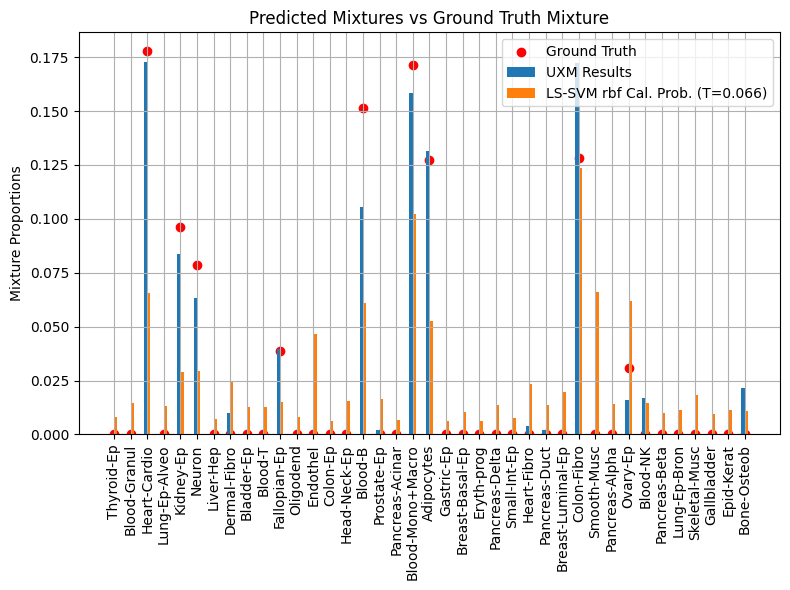

In [27]:
# Visualize the predictions of the LS-SVM on a single sample from the unpure mixtures, compared to the UxM results and the ground truth mixture
lssvm = MulticlassLSSVM(kernel=lssvm_kernel)
with suppress_many_unique_classes_warning():
    lssvm.fit(X_pure_train_full, y_pure_train * 2 - 1)
    X_pure_val_pred = lssvm.predict(X_pure_val_full)

calibrated_T = find_temperature_for_confidence(
    X_pure_val_pred, y_pure_val_labels, target_confidence=0.999, min_pass_count=20
)

unpure_mixture_idx = 2
lssvm_unpure_pred = lssvm.predict(
    X_unpure_train_full[unpure_mixture_idx].reshape(1, -1)
).squeeze()
ground_truth_unpure_mixture = get_unpure_ground_truth_mixture(unpure_mixture_idx)

plot_mixtures_pred_vs_true(
    ground_truth_mixture=ground_truth_unpure_mixture,
    predicted_mixtures=[
        get_unpure_uxm_results(unpure_mixture_idx, "train"),
        softmax(lssvm_unpure_pred.reshape(1, -1), T=calibrated_T).squeeze(),
    ],
    predicted_mixture_labels=[
        "UXM Results",
        f"LS-SVM {lssvm_kernel} Cal. Prob. (T={calibrated_T:.3f})",
    ],
)

We now evaluation LS-SVM on all the unpure mixtures, testing different settings:

- varying the temperature of the softmax function
- using Linear or RBF kernels

In [ ]:
# Evaluate UXM and LS-SVM on all unpure mixtures and store metrics in a single DataFrame
temperatures_to_test = 10 ** np.linspace(-3, 1, num=10)
additional_temperatures_to_test = 10 ** np.linspace(-2, -1, num=15)
temperatures_to_test = np.sort(
    np.unique(np.concatenate([temperatures_to_test, additional_temperatures_to_test]))
)
kernels_to_test = ["linear", "rbf"]

split_names = ["train", "val", "test"]
n_mixtures = y_unpure_by_split["train"].shape[0]

# Train one LS-SVM per kernel
lssvm_models = {}
for kernel in kernels_to_test:
    lssvm_model = MulticlassLSSVM(kernel=kernel)
    with suppress_many_unique_classes_warning():
        lssvm_model.fit(X_pure_train_full, y_pure_train * 2 - 1)
    lssvm_models[kernel] = lssvm_model

results = []

# Compute UXM metrics once per split
uxm_preds_by_split = {
    split_name: np.vstack(
        [
            get_unpure_uxm_results(mixture_idx, split_name)
            for mixture_idx in range(n_mixtures)
        ]
    )
    for split_name in split_names
}

for split_name in split_names:
    uxm_metrics = compute_deconvolution_metrics(
        uxm_preds_by_split[split_name],
        y_unpure_by_split[split_name],
    )
    results.append(
        {
            "model": "UXM",
            "kernel": np.nan,
            "temperature": np.nan,
            "split": split_name,
            **uxm_metrics,
        }
    )

# Compute LS-SVM metrics for each kernel and temperature
for kernel, lssvm_model in lssvm_models.items():
    raw_preds_by_split = {
        split_name: lssvm_model.predict(X_unpure_full_by_split[split_name])
        for split_name in split_names
    }

    for T in temperatures_to_test:
        for split_name in split_names:
            lssvm_probs = softmax(raw_preds_by_split[split_name], T=T)
            lssvm_metrics = compute_deconvolution_metrics(
                lssvm_probs,
                y_unpure_by_split[split_name],
            )
            results.append(
                {
                    "model": "LS-SVM",
                    "kernel": kernel,
                    "temperature": T,
                    "split": split_name,
                    **lssvm_metrics,
                }
            )

unpure_metrics_df = pd.DataFrame(results).sort_values(["split", "mse"])

unpure_metrics_df

,model,kernel,temperature,split,mae,mse,kl,max_error,cosine_sim
2,UXM,NaN,NaN,test,0.004698,0.000205,0.127817,0.362574,0.991525
131,LS-SVM,rbf,0.071969,test,0.021928,0.002148,0.733848,0.750344,0.857671
134,LS-SVM,rbf,0.084834,test,0.023954,0.002210,0.790206,0.811235,0.845765
128,LS-SVM,rbf,0.061054,test,0.020337,0.002250,0.709570,0.666420,0.861723
125,LS-SVM,rbf,0.059948,test,0.020188,0.002272,0.709162,0.655508,0.861722
...,...,...,...,...,...,...,...,...,...
10,LS-SVM,linear,0.007743,val,0.027849,0.011530,5.199670,0.972164,0.689172
82,LS-SVM,rbf,0.002783,val,0.029455,0.012760,7.663670,1.000000,0.664762
7,LS-SVM,linear,0.002783,val,0.029864,0.013352,8.150726,0.999949,0.661396
79,LS-SVM,rbf,0.001000,val,0.030324,0.013686,9.035728,1.000000,0.653191


Visualization of the results with different temperature and kernel settings.

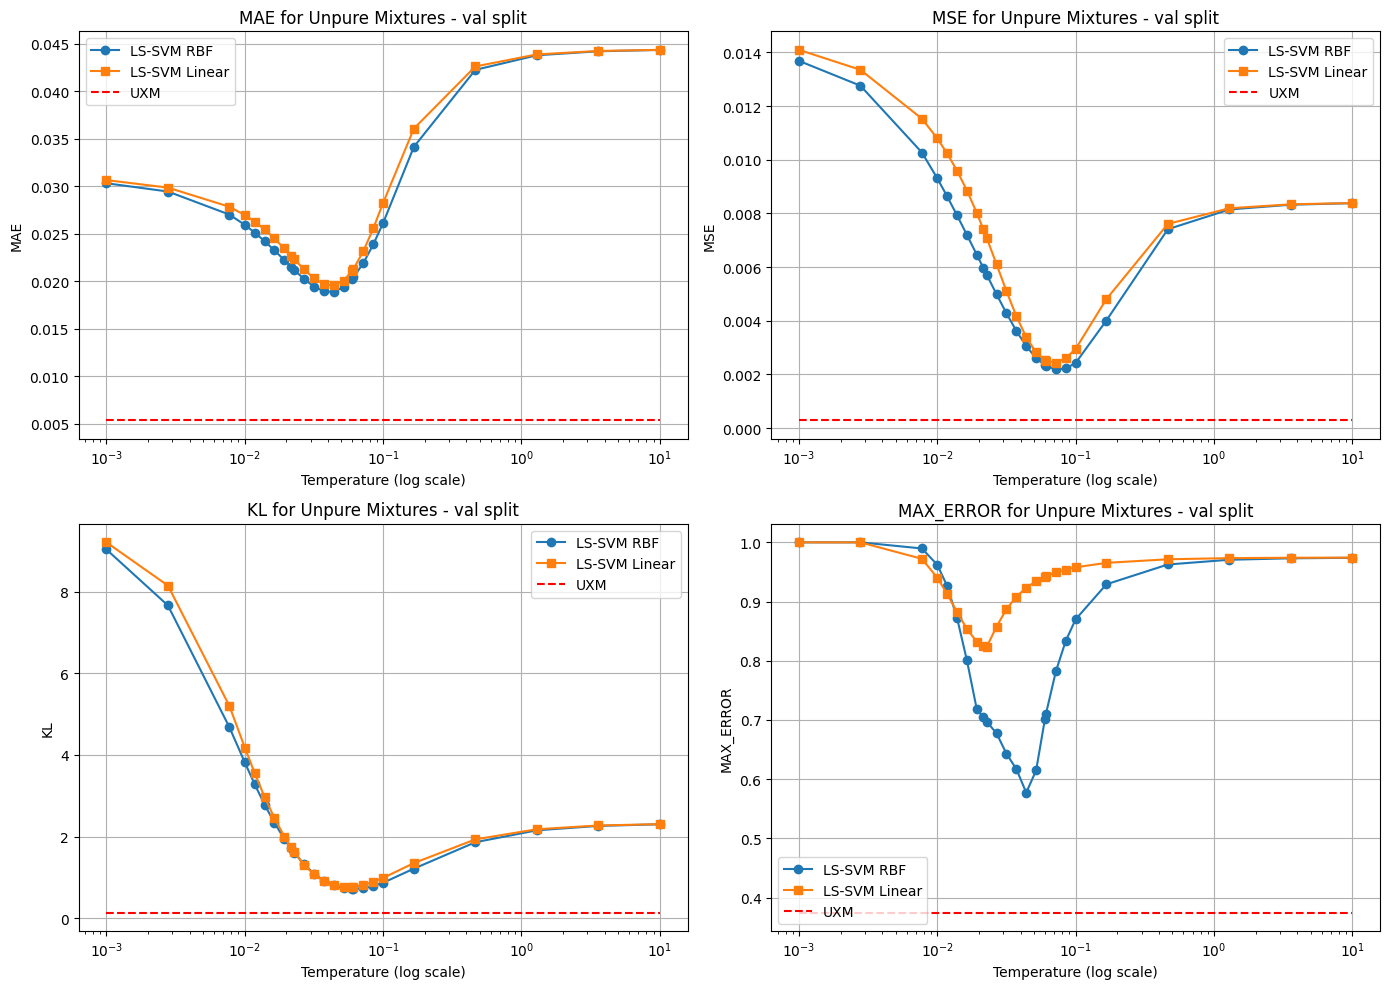

In [29]:
# plot deconvolution metrics for the unpure mixtures as a function of the temperature
# for both "rbf" and "linear" kernels; the UXM baseline is plotted as a horizontal line
split = "val"

rbf_metrics = unpure_metrics_df[
    (unpure_metrics_df["model"] == "LS-SVM")
    & (unpure_metrics_df["kernel"] == "rbf")
    & (unpure_metrics_df["split"] == split)
].sort_values("temperature")

linear_metrics = unpure_metrics_df[
    (unpure_metrics_df["model"] == "LS-SVM")
    & (unpure_metrics_df["kernel"] == "linear")
    & (unpure_metrics_df["split"] == split)
].sort_values("temperature")

uxm_metrics = unpure_metrics_df[
    (unpure_metrics_df["model"] == "UXM") & (unpure_metrics_df["split"] == split)
]

metrics_to_plot = ["mae", "mse", "kl", "max_error"]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

xmin = min(rbf_metrics["temperature"].min(), linear_metrics["temperature"].min())
xmax = max(rbf_metrics["temperature"].max(), linear_metrics["temperature"].max())

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx]
    ax.plot(
        rbf_metrics["temperature"],
        rbf_metrics[metric],
        marker="o",
        label="LS-SVM RBF",
    )
    ax.plot(
        linear_metrics["temperature"],
        linear_metrics[metric],
        marker="s",
        label="LS-SVM Linear",
    )
    ax.hlines(
        uxm_metrics[metric].values[0],
        xmin=xmin,
        xmax=xmax,
        colors="red",
        linestyles="dashed",
        label="UXM",
    )
    ax.set_xscale("log")
    ax.set_xlabel("Temperature (log scale)")
    ax.set_ylabel(metric.upper())
    ax.set_title(f"{metric.upper()} for Unpure Mixtures - {split} split")
    ax.legend()
    ax.grid()

plt.tight_layout()
plt.show()

We now get the best temperature and kernel settings, and we visualize the predicted proportions for the mixtures with the best and worst performance, compared to the UxM results and the ground truth mixture.

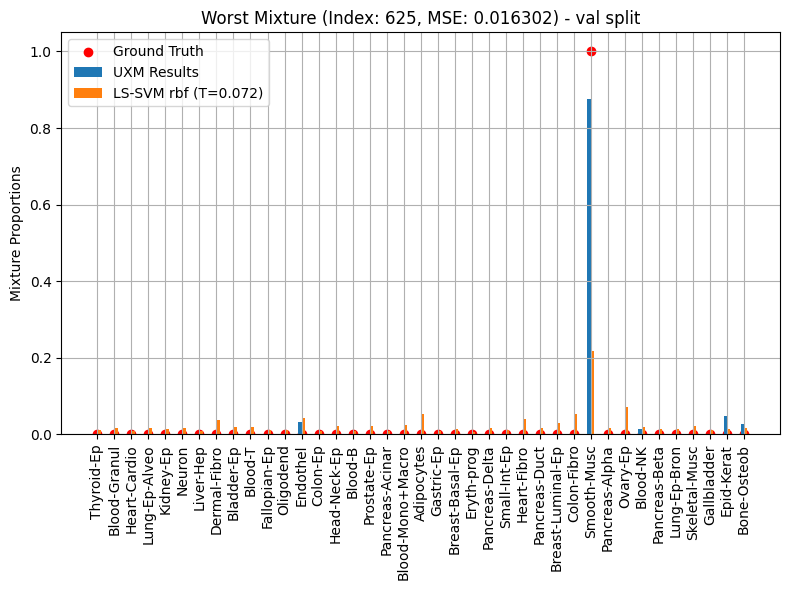

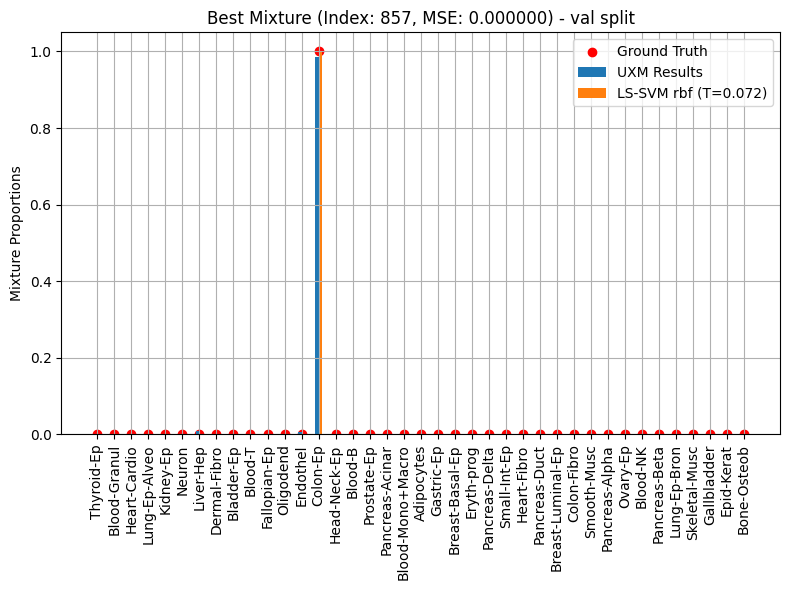

Worst mixture index: 625, MSE: 0.016302
Best mixture index: 857, MSE: 0.000000


In [30]:
# Select the best LS-SVM model in terms of MSE
best_lssvm_row = (
    unpure_metrics_df[
        (unpure_metrics_df["model"] == "LS-SVM") & (unpure_metrics_df["split"] == "val")
    ]
    .sort_values("mse")
    .iloc[0]
)

best_lssvm_model = lssvm_models[best_lssvm_row["kernel"]]
best_lssvm_T = best_lssvm_row["temperature"]

# Get all LS-SVM predictions on validation set
lssvm_val_raw_preds = best_lssvm_model.predict(X_unpure_val_full)
lssvm_val_preds = softmax(lssvm_val_raw_preds, T=best_lssvm_T)

# Compute MSE for each mixture
mse_per_mixture = np.mean((lssvm_val_preds - y_unpure_val) ** 2, axis=1)

# Find worst and best mixtures
worst_mixture_idx = np.argmax(mse_per_mixture)
best_mixture_idx = np.argmin(mse_per_mixture)

# Plot worst mixture
plot_mixtures_pred_vs_true(
    ground_truth_mixture=y_unpure_val[worst_mixture_idx],
    predicted_mixtures=[
        get_unpure_uxm_results(worst_mixture_idx, "val"),
        lssvm_val_preds[worst_mixture_idx],
    ],
    predicted_mixture_labels=[
        "UXM Results",
        f"LS-SVM {best_lssvm_row['kernel']} (T={best_lssvm_T:.3f})",
    ],
    title=f"Worst Mixture (Index: {worst_mixture_idx}, MSE: {mse_per_mixture[worst_mixture_idx]:.6f}) - {split} split",
)

# Plot best mixture
plot_mixtures_pred_vs_true(
    ground_truth_mixture=y_unpure_val[best_mixture_idx],
    predicted_mixtures=[
        get_unpure_uxm_results(best_mixture_idx, "val"),
        lssvm_val_preds[best_mixture_idx],
    ],
    predicted_mixture_labels=[
        "UXM Results",
        f"LS-SVM {best_lssvm_row['kernel']} (T={best_lssvm_T:.3f})",
    ],
    title=f"Best Mixture (Index: {best_mixture_idx}, MSE: {mse_per_mixture[best_mixture_idx]:.6f}) - {split} split",
)

print(
    f"Worst mixture index: {worst_mixture_idx}, MSE: {mse_per_mixture[worst_mixture_idx]:.6f}"
)
print(
    f"Best mixture index: {best_mixture_idx}, MSE: {mse_per_mixture[best_mixture_idx]:.6f}"
)

### 5.3. ECOC with SVM and binary LS-SVM as base estimators

In this section, we use the error correcting output codes (ECOC) strategy to construct a multi-class classifier based on many binary classifiers (SVC).

The idea is to assign one binary code to each class (cell type) and to train one binary SVC for each bit of the code block.

Contrary to classical ECOC where we want to predict a class, here we need to predict a proportion for each class.

We test several ways to do that:
- aggregate scores of each estimator into a single score for each class and then apply a softmax with temperature to obtain predicted proportions (that's the strategy explained on an example in section 5.3.1)
- apply a logistic regression on top of the scores of the binary classifiers to directly predict the proportions (logreg trained using only the pure mixtures)
- train a linear layer + softmax on top of the scores of the binary classifiers to predict the proportions

#### 5.3.1. Example of the idea of the method

Assume 4 classes with codewords of length 14with the following code matrix.

In [31]:
example_code_matrix_precursor = [
    "0001",
    "0010",
    "0011",
    "0100",
    "0101",
    "0110",
    "0111",
    "1000",
    "1001",
    "1010",
    "1011",
    "1100",
    "1101",
    "1110",
]
example_code_matrix = np.array(
    [[int(bit) for bit in code] for code in example_code_matrix_precursor]
).T
example_code_matrix_m1p1 = example_code_matrix * 2 - 1
example_code_matrix

array([[0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1],
       [0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1],
       [0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1],
       [1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0]])

The assume that we have trained the 14 binary LS-SVMs and that their outputs (in [-1,1]) corresponds perfectly to the mixtures, ie:
- For input mixture A: [1, 0, 0, 0] the output of the 14 binary LS-SVMs is code_matrix[0, :]*2-1
- For input mixture B: [0, 1, 0, 0] the output of the 14 binary LS-SVMs is code_matrix[1, :]*2-1
- For input mixture C: [0, 0.5, 0, 0.5] the output of the 14 binary LS-SVMs is code_matrix[1, :]*2-1*0.5 + code_matrix[3, :]*2-1*0.5
- For input mixture D: [0.25, 0.25, 0.25, 0.25] the output of the 14 binary LS-SVMs is code_matrix[0, :]*2-1*0.25 + code_matrix[1, :]*2-1*0.25 + code_matrix[2, :]*2-1*0.25 + code_matrix[3, :]*2-1*0.25

In [32]:
for example_mixture in [
    [1, 0, 0, 0],
    [0.5, 0.5, 0, 0],
    [0.25, 0.25, 0.25, 0.25],
    [0.1, 0.2, 0.3, 0.4],
    [0.8, 0.1, 0.05, 0.05],
]:
    example_mixture_output = np.array(example_mixture) @ example_code_matrix_m1p1
    example_aggregation_results = example_code_matrix_m1p1 @ example_mixture_output
    example_softmax_results = softmax(example_aggregation_results, T=4)
    print(
        f"Mixture: {example_mixture} -> Aggregation results: {example_aggregation_results} -> Softmax results: {example_softmax_results.round(2)}"
    )

Mixture: [1, 0, 0, 0] -> Aggregation results: [14 -2 -2 -2] -> Softmax results: [0.95 0.02 0.02 0.02]
Mixture: [0.5, 0.5, 0, 0] -> Aggregation results: [ 6.  6. -2. -2.] -> Softmax results: [0.44 0.44 0.06 0.06]
Mixture: [0.25, 0.25, 0.25, 0.25] -> Aggregation results: [2. 2. 2. 2.] -> Softmax results: [0.25 0.25 0.25 0.25]
Mixture: [0.1, 0.2, 0.3, 0.4] -> Aggregation results: [-0.4  1.2  2.8  4.4] -> Softmax results: [0.12 0.19 0.28 0.41]
Mixture: [0.8, 0.1, 0.05, 0.05] -> Aggregation results: [10.8 -0.4 -1.2 -1.2] -> Softmax results: [0.86 0.05 0.04 0.04]


#### 5.3.4. ECOC+SVM+Softmax With Temperature

We give another go at regular SVMs, but this time using the ECOC strategy to see if we can get better score segregation and better calibrated probabilities.

The results are not good, it confirms that the issue of score seggregation of regular SVMs. We stop using regular SVMs after that.

In [33]:
# training on pure mixtures
ecoc_svc = CustomECOC(
    base_estimator=SVC(kernel="rbf"),
    n_bits=500,
    n_classes=39,
    matrix_construction_mode="full_random",
    random_state=42,
)
with suppress_many_unique_classes_warning():
    ecoc_svc.fit(X_pure_train_full, y_pure_train_labels)

In [34]:
# check that the accuracy is 100% on the training set
(
    ecoc_svc.decision_function(X_pure_train_full).argmax(axis=1) == y_pure_train_labels
).mean()

np.float64(1.0)

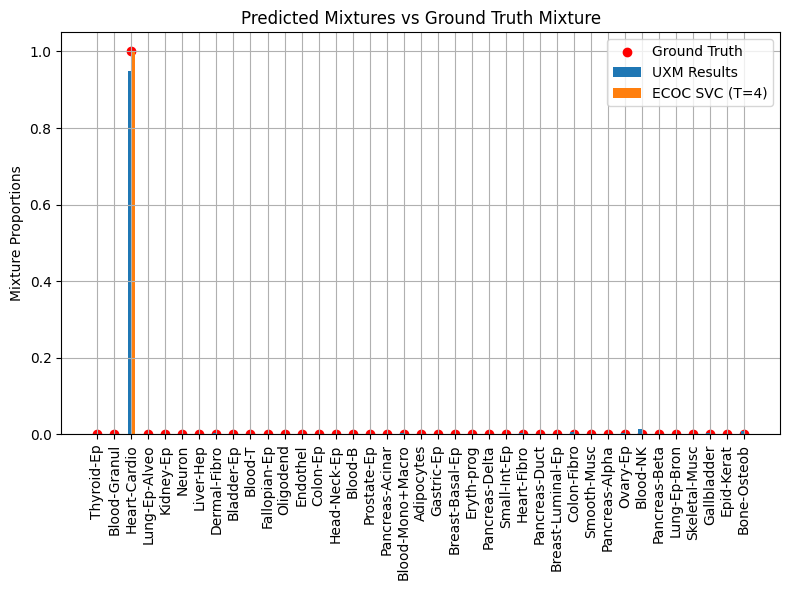

In [35]:
# visualize the predicted mixtures for the pure training samples using the ECOC SVC
pure_mixture_idx = 2
split_name = "train"
ground_truth_pure_mixture = get_pure_ground_truth_mixture(pure_mixture_idx)
ecoc_svc_raw_prediction = ecoc_svc.decision_function(
    X_pure_full_by_split[split_name][pure_mixture_idx].reshape(1, -1)
).squeeze(0)

plot_mixtures_pred_vs_true(
    ground_truth_mixture=ground_truth_pure_mixture,
    predicted_mixtures=[
        get_pure_uxm_results(pure_mixture_idx, split_name),
        softmax(ecoc_svc_raw_prediction, T=0.05),
    ],
    predicted_mixture_labels=[
        "UXM Results",
        f"ECOC SVC (T=4)",
    ],
)

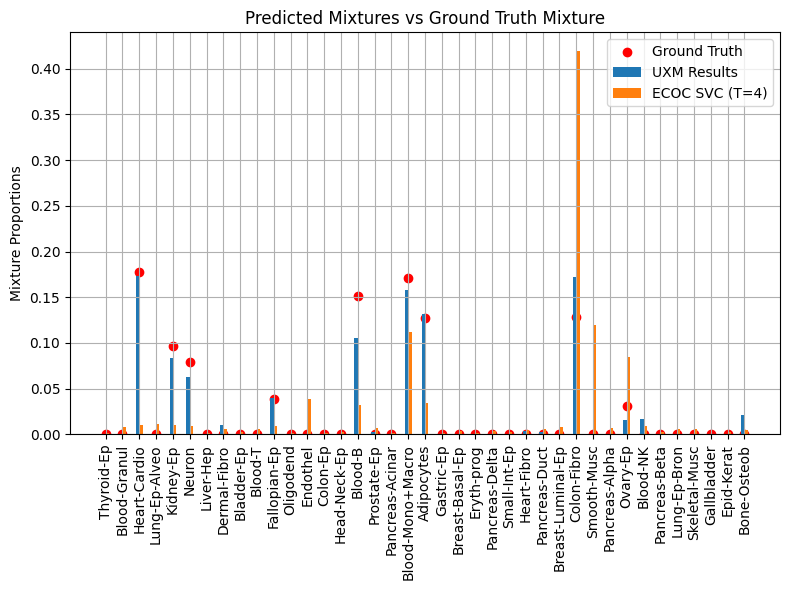

In [36]:
# visualize the predicted mixtures for one unpure training sample using the ECOC SVC
unpure_mixture_idx = 2
split_name = "train"
ground_truth_unpure_mixture = get_unpure_ground_truth_mixture(unpure_mixture_idx)
ecoc_svc_raw_prediction = ecoc_svc.decision_function(
    X_unpure_full_by_split[split_name][unpure_mixture_idx].reshape(1, -1)
).squeeze(0)

plot_mixtures_pred_vs_true(
    ground_truth_mixture=ground_truth_unpure_mixture,
    predicted_mixtures=[
        get_unpure_uxm_results(unpure_mixture_idx, split_name),
        softmax(ecoc_svc_raw_prediction, T=0.05),
    ],
    predicted_mixture_labels=[
        "UXM Results",
        f"ECOC SVC (T=4)",
    ],
)

In [ ]:
# compute deconvolution metrics for ECOC-SVC models trained with different n_bits
# and compare them to UXM results in a single DataFrame

# editable parameters
split_names = ["val"]
n_bits_list = [50, 1000]
n_workers = 8
temperatures_to_test = np.sort(
    np.unique(np.concatenate([10 ** np.linspace(-2, -0.5, num=6), []]))
)
ecoc_kernel = "rbf"
ecoc_random_state = 42

n_classes = y_pure_train.shape[1]
ecoc_svc_models = {}
ecoc_results = []

# UXM baseline
for split_name in split_names:
    n_mixtures = y_unpure_by_split[split_name].shape[0]
    uxm_pred = np.vstack(
        [
            get_unpure_uxm_results(mixture_idx, split_name)
            for mixture_idx in range(n_mixtures)
        ]
    )
    uxm_metrics = compute_deconvolution_metrics(uxm_pred, y_unpure_by_split[split_name])
    ecoc_results.append(
        {
            "model": "UXM",
            "n_bits": np.nan,
            "temperature": np.nan,
            "split": split_name,
            "label_accuracy": float(
                np.mean(
                    np.argmax(uxm_pred, axis=1)
                    == np.argmax(y_unpure_by_split[split_name], axis=1)
                )
            ),
            **uxm_metrics,
        }
    )

# Train one ECOC-SVC per n_bits and evaluate all temperatures
n_loops = len(n_bits_list) * len(temperatures_to_test) * len(split_names)
with tqdm(total=n_loops, desc="Evaluating ECOC-SVC models") as pbar:
    for n_bits in n_bits_list:
        ecoc_svc_model = CustomECOC(
            base_estimator=SVC(kernel=ecoc_kernel),
            n_bits=n_bits,
            n_classes=n_classes,
            matrix_construction_mode="full_random",
            random_state=ecoc_random_state,
            decision_function_workers=n_workers,
        )

        with suppress_many_unique_classes_warning():
            ecoc_svc_model.fit(X_pure_train_full, y_pure_train_labels)
            ecoc_svc_models[n_bits] = ecoc_svc_model

            ecoc_raw_by_split = {
                split_name: ecoc_svc_model.decision_function(
                    X_unpure_full_by_split[split_name]
                )
                for split_name in split_names
            }

        for T in temperatures_to_test:
            for split_name in split_names:
                pbar.set_postfix_str(f"n_bits={n_bits}, T={T:.3f}, split={split_name}")
                ecoc_pred = softmax(ecoc_raw_by_split[split_name], T=T)
                ecoc_metrics = compute_deconvolution_metrics(
                    ecoc_pred, y_unpure_by_split[split_name]
                )
                ecoc_results.append(
                    {
                        "model": "ECOC-SVC",
                        "n_bits": int(n_bits),
                        "temperature": float(T),
                        "split": split_name,
                        "label_accuracy": float(
                            np.mean(
                                np.argmax(ecoc_pred, axis=1)
                                == np.argmax(y_unpure_by_split[split_name], axis=1)
                            )
                        ),
                        **ecoc_metrics,
                    }
                )
                pbar.update(1)

ecoc_metrics_df = pd.DataFrame(ecoc_results).sort_values(
    ["split", "model", "n_bits", "mse", "temperature"]
)
ecoc_metrics_df

Evaluating ECOC-SVC models:   0%|          | 0/12 [00:00<?, ?it/s]

,model,n_bits,temperature,split,label_accuracy,mae,mse,kl,max_error,cosine_sim
4,ECOC-SVC,50.0,0.079433,val,0.452,0.028236,0.003772,1.274663,0.747349,0.628437
5,ECOC-SVC,50.0,0.158489,val,0.452,0.034818,0.004310,1.353958,0.893430,0.631753
6,ECOC-SVC,50.0,0.316228,val,0.452,0.041030,0.006746,1.721627,0.944047,0.527993
3,ECOC-SVC,50.0,0.039811,val,0.452,0.028920,0.006936,2.137731,0.883605,0.563397
2,ECOC-SVC,50.0,0.019953,val,0.452,0.031479,0.011285,4.553966,0.994949,0.516195
1,ECOC-SVC,50.0,0.010000,val,0.452,0.033134,0.014502,7.783010,0.999993,0.491529
10,ECOC-SVC,1000.0,0.079433,val,0.650,0.024859,0.002496,0.908796,0.767585,0.781237
11,ECOC-SVC,1000.0,0.158489,val,0.650,0.033894,0.003854,1.232800,0.909892,0.702437
9,ECOC-SVC,1000.0,0.039811,val,0.650,0.022005,0.003934,1.170242,0.758576,0.748842
12,ECOC-SVC,1000.0,0.316228,val,0.650,0.040870,0.006619,1.685487,0.950228,0.550326


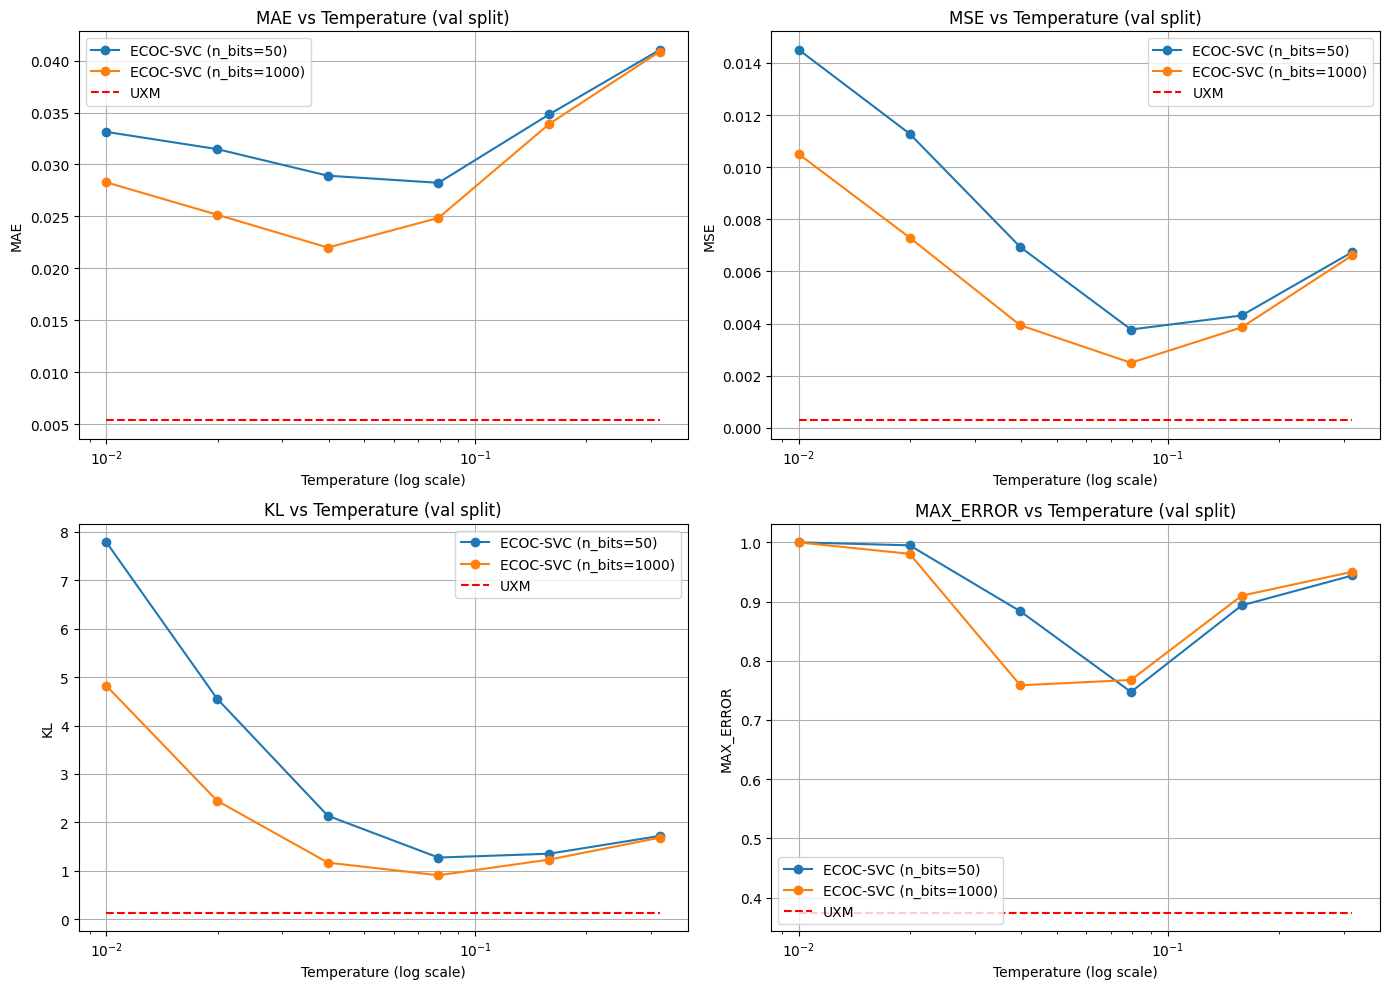

In [38]:
# plot in 4 subplots the deconvolution metrics for the ECOC SVC as a function of the temperature a given split, with the UXM baseline as a horizontal line
split = "val"
ecoc_split_metrics = ecoc_metrics_df[
    (ecoc_metrics_df["model"] == "ECOC-SVC") & (ecoc_metrics_df["split"] == split)
].sort_values("temperature")

uxm_split_metrics = ecoc_metrics_df[
    (ecoc_metrics_df["model"] == "UXM") & (ecoc_metrics_df["split"] == split)
]

if ecoc_split_metrics.empty or uxm_split_metrics.empty:
    raise ValueError(f"No ECOC/UXM metrics found for split='{split}'")

metrics_to_plot = ["mae", "mse", "kl", "max_error"]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

x_min = ecoc_split_metrics["temperature"].min()
x_max = ecoc_split_metrics["temperature"].max()

for ax, metric in zip(axes, metrics_to_plot):
    for n_bits, group in ecoc_split_metrics.groupby("n_bits"):
        group = group.sort_values("temperature")
        ax.plot(
            group["temperature"],
            group[metric],
            marker="o",
            label=f"ECOC-SVC (n_bits={int(n_bits)})",
        )
    ax.hlines(
        y=uxm_split_metrics[metric].iloc[0],
        xmin=x_min,
        xmax=x_max,
        colors="red",
        linestyles="dashed",
        label="UXM",
    )
    ax.set_xscale("log")
    ax.set_xlabel("Temperature (log scale)")
    ax.set_ylabel(metric.upper())
    ax.set_title(f"{metric.upper()} vs Temperature ({split} split)")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

#### 5.3.5. ECOC + binary LS-SVM + SoftMax with Temperature

ECOC uses binary classifiers as base estimators, so we introduce standard binary LS-SVMs as base estimators in the ECOC strategy, and we apply a softmax with temperature on top of the scores of the binary LS-SVMs to get predicted proportions.

In [39]:
ecoc_lssvm = CustomECOC(
    base_estimator=BinaryLSSVM(gamma=1.0, sigma=1.0, kernel="rbf"),
    n_bits=50,
    n_classes=39,
    matrix_construction_mode="full_random",
    random_state=42,
)
with suppress_many_unique_classes_warning():
    ecoc_lssvm.fit(X_pure_train_full, y_pure_train_labels)

# check that the accuracy is 100% on the training set
(
    ecoc_lssvm.decision_function(X_pure_train_full).argmax(axis=1)
    == y_pure_train_labels
).mean()

np.float64(1.0)

In [ ]:
# compute deconvolution metrics for ECOC-LSSVM models trained with different n_bits
# compare them to UXM results in a single DataFrame, while also scanning softmax temperatures

splits_to_evaluate = ["val"]
n_bits_for_lssvm = [50, 500, 1500]
temperatures_to_test = np.sort(
    np.unique(np.concatenate([10 ** np.linspace(-3, 0, num=9), []]))
)

# ECOC-LSSVM base estimator hyperparameters
ecoc_lssvm_kernel = "rbf"
ecoc_lssvm_gamma = 1.0
ecoc_lssvm_sigma = 1.0
ecoc_lssvm_random_state = 42
ecoc_lssvm_n_workers = 8

n_classes = y_pure_train.shape[1]
n_mixtures = y_unpure_by_split[splits_to_evaluate[0]].shape[0]

ecoc_lssvm_models = {}
ecoc_lssvm_results = []

# UXM baseline
for split_name in splits_to_evaluate:
    uxm_pred = np.vstack(
        [
            get_unpure_uxm_results(mixture_idx, split_name)
            for mixture_idx in range(n_mixtures)
        ]
    )
    uxm_metrics = compute_deconvolution_metrics(uxm_pred, y_unpure_by_split[split_name])
    ecoc_lssvm_results.append(
        {
            "model": "UXM",
            "n_bits": np.nan,
            "temperature": np.nan,
            "split": split_name,
            "label_accuracy": float(
                np.mean(
                    np.argmax(uxm_pred, axis=1)
                    == np.argmax(y_unpure_by_split[split_name], axis=1)
                )
            ),
            **uxm_metrics,
        }
    )

# ECOC-LSSVM results
n_loops = len(n_bits_for_lssvm) * len(temperatures_to_test) * len(splits_to_evaluate)
with tqdm(total=n_loops, desc="Evaluating ECOC-LSSVM models") as pbar:
    for n_bits in n_bits_for_lssvm:
        ecoc_lssvm_model = CustomECOC(
            base_estimator=BinaryLSSVM(
                gamma=ecoc_lssvm_gamma,
                sigma=ecoc_lssvm_sigma,
                kernel=ecoc_lssvm_kernel,
            ),
            n_bits=n_bits,
            n_classes=n_classes,
            matrix_construction_mode="full_random",
            random_state=ecoc_lssvm_random_state,
            decision_function_workers=ecoc_lssvm_n_workers,
        )

        with suppress_many_unique_classes_warning():
            ecoc_lssvm_model.fit(X_pure_train_full, y_pure_train_labels)
            ecoc_lssvm_models[n_bits] = ecoc_lssvm_model

            ecoc_raw_by_split = {
                split_name: ecoc_lssvm_model.decision_function(
                    X_unpure_full_by_split[split_name]
                )
                for split_name in splits_to_evaluate
            }

        for T in temperatures_to_test:
            for split_name in splits_to_evaluate:
                pbar.set_postfix_str(f"n_bits={n_bits}, T={T:.3g}, split={split_name}")
                ecoc_pred = softmax(ecoc_raw_by_split[split_name], T=T)
                ecoc_metrics = compute_deconvolution_metrics(
                    ecoc_pred, y_unpure_by_split[split_name]
                )
                ecoc_lssvm_results.append(
                    {
                        "model": "ECOC-LSSVM",
                        "n_bits": int(n_bits),
                        "temperature": float(T),
                        "split": split_name,
                        "label_accuracy": float(
                            np.mean(
                                np.argmax(ecoc_pred, axis=1)
                                == np.argmax(y_unpure_by_split[split_name], axis=1)
                            )
                        ),
                        **ecoc_metrics,
                    }
                )
                pbar.update(1)

ecoc_lssvm_metrics_df = pd.DataFrame(ecoc_lssvm_results).sort_values(
    ["split", "model", "n_bits", "mse", "temperature"]
)

ecoc_lssvm_metrics_df

Evaluating ECOC-LSSVM models:   0%|          | 0/27 [00:00<?, ?it/s]

,model,n_bits,temperature,split,label_accuracy,mae,mse,kl,max_error,cosine_sim
5,ECOC-LSSVM,50.0,0.031623,val,0.565,0.023715,0.003022,1.002534,0.755934,0.742897
6,ECOC-LSSVM,50.0,0.074989,val,0.565,0.033337,0.003906,1.221949,0.920275,0.698787
4,ECOC-LSSVM,50.0,0.013335,val,0.565,0.025579,0.006893,2.101822,0.943154,0.668960
7,ECOC-LSSVM,50.0,0.177828,val,0.565,0.041352,0.006982,1.750183,0.957396,0.520196
8,ECOC-LSSVM,50.0,0.421697,val,0.565,0.043399,0.007977,2.068600,0.968081,0.392512
9,ECOC-LSSVM,50.0,1.000000,val,0.565,0.044028,0.008251,2.214436,0.971854,0.345701
3,ECOC-LSSVM,50.0,0.005623,val,0.565,0.029249,0.011404,5.151391,0.999393,0.614617
2,ECOC-LSSVM,50.0,0.002371,val,0.565,0.031039,0.013821,8.130855,1.000000,0.591606
1,ECOC-LSSVM,50.0,0.001000,val,0.565,0.031779,0.014911,9.458117,1.000000,0.582570
14,ECOC-LSSVM,500.0,0.031623,val,0.676,0.020941,0.002377,0.746944,0.749128,0.844932


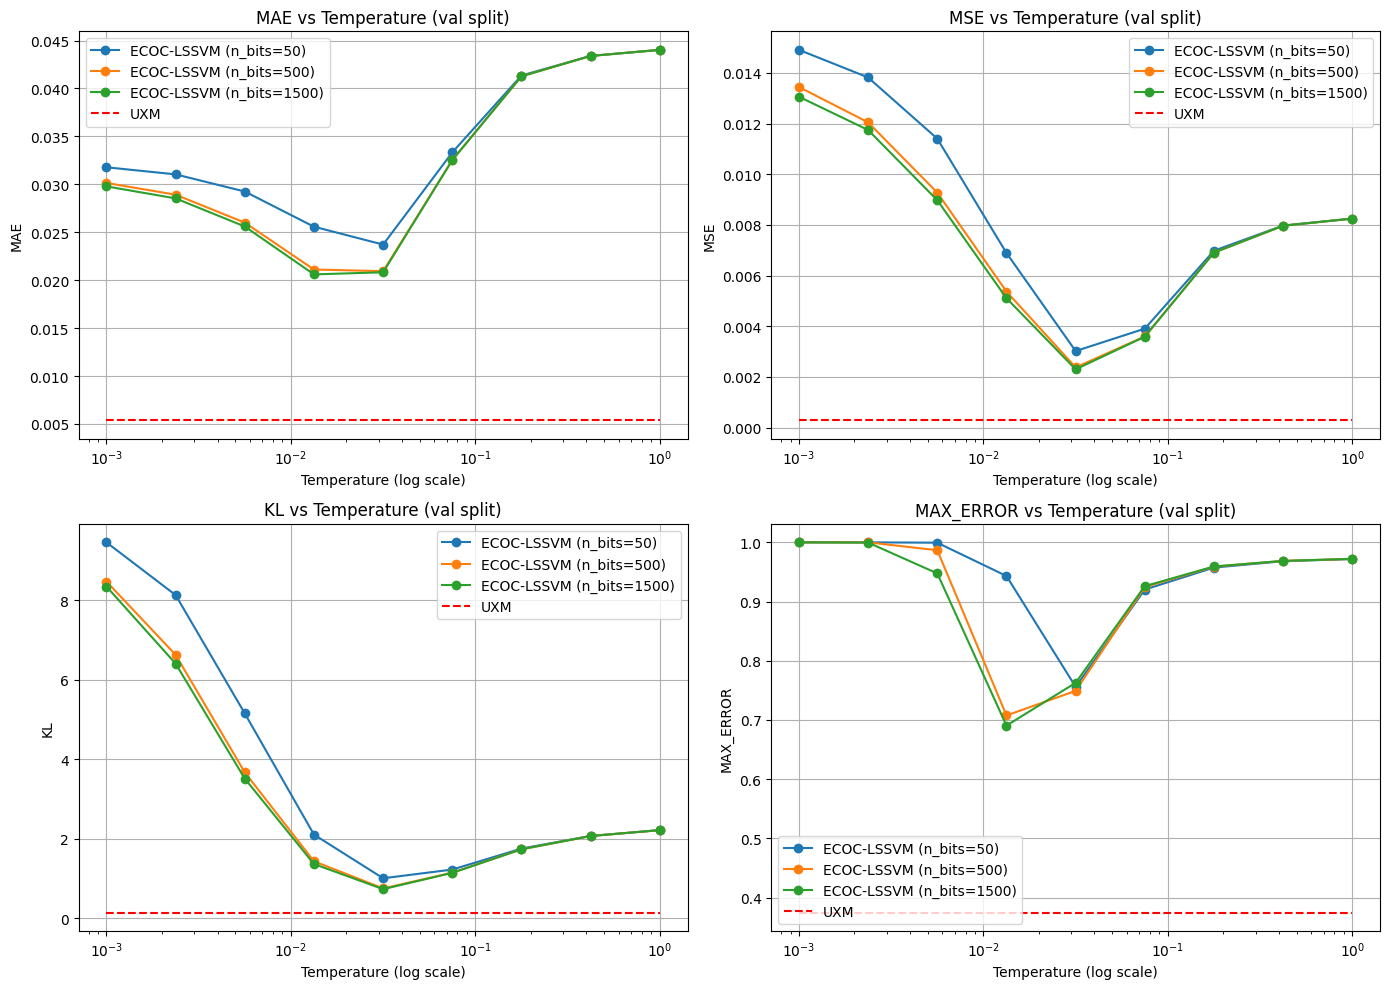

In [41]:
# plot 4 subplots the deconvolution metrics for the ECOC LSSVM as a function of the temperature a given split, with the UXM baseline as a horizontal line
split = "val"

ecoc_lssvm_split_metrics = ecoc_lssvm_metrics_df[
    (ecoc_lssvm_metrics_df["model"] == "ECOC-LSSVM")
    & (ecoc_lssvm_metrics_df["split"] == split)
].sort_values("temperature")

uxm_split_metrics = ecoc_lssvm_metrics_df[
    (ecoc_lssvm_metrics_df["model"] == "UXM")
    & (ecoc_lssvm_metrics_df["split"] == split)
]

if ecoc_lssvm_split_metrics.empty or uxm_split_metrics.empty:
    raise ValueError(f"No ECOC-LSSVM/UXM metrics found for split='{split}'")

metrics_to_plot = ["mae", "mse", "kl", "max_error"]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

temp_min = ecoc_lssvm_split_metrics["temperature"].min()
temp_max = ecoc_lssvm_split_metrics["temperature"].max()

for ax, metric in zip(axes, metrics_to_plot):
    for n_bits, group in ecoc_lssvm_split_metrics.groupby("n_bits"):
        group = group.sort_values("temperature")
        ax.plot(
            group["temperature"],
            group[metric],
            marker="o",
            label=f"ECOC-LSSVM (n_bits={int(n_bits)})",
        )

    ax.hlines(
        y=uxm_split_metrics[metric].iloc[0],
        xmin=temp_min,
        xmax=temp_max,
        colors="red",
        linestyles="dashed",
        label="UXM",
    )
    ax.set_xscale("log")
    ax.set_xlabel("Temperature (log scale)")
    ax.set_ylabel(metric.upper())
    ax.set_title(f"{metric.upper()} vs Temperature ({split} split)")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

The results of ECOC + binary LS-SVM + SoftMax with Temperature are pretty much the same as the results of the Multiclass LS-SVM: not completely bad but still much worse than UXM.

#### 5.3.6. ECOC + binary LS-SVM + Logistic Regression (trained on pure mixtures)

Here we use the probabilities predicted by a logistic regression trained on the pure mixtures on top of the scores of the binary LS-SVMs as predicted proportions.

The results are worse than ECOC + binary LS-SVM + SoftMax with Temperature, which can be explained by the fact that the logistic regression is trained only on the pure mixtures and thus has no way to calibrate agaist unpure mixtures (unlike the softmax with temperature where we adjust the temperature to calibrate the probabilities on the unpure mixtures).

In [ ]:
# compute deconvolution metrics for ECOC-LSSVM+Logreg models trained with different n_bits
# compare them to UXM results in a single DataFrame, while also scanning softmax temperatures
splits_to_evaluate = ["val"]
n_bits_for_lssvm = [50, 500]

# ECOC-LSSVM base estimator hyperparameters
ecoc_lssvm_kernel = "rbf"
ecoc_lssvm_gamma = 1.0
ecoc_lssvm_sigma = 1.0
ecoc_lssvm_random_state = 42
ecoc_lssvm_n_workers = 8

n_classes = y_pure_train.shape[1]
n_mixtures = y_unpure_by_split[splits_to_evaluate[0]].shape[0]

ecoc_lssvm_logreg_models = {}
ecoc_lssvm_logreg_results = []

# UXM baseline
for split_name in splits_to_evaluate:
    uxm_pred = np.vstack(
        [
            get_unpure_uxm_results(mixture_idx, split_name)
            for mixture_idx in range(n_mixtures)
        ]
    )
    uxm_metrics = compute_deconvolution_metrics(uxm_pred, y_unpure_by_split[split_name])
    ecoc_lssvm_logreg_results.append(
        {
            "model": "UXM",
            "n_bits": np.nan,
            "split": split_name,
            "label_accuracy": float(
                np.mean(
                    np.argmax(uxm_pred, axis=1)
                    == np.argmax(y_unpure_by_split[split_name], axis=1)
                )
            ),
            **uxm_metrics,
        }
    )

# ECOC-LSSVM results
n_loops = len(n_bits_for_lssvm) * len(splits_to_evaluate)
with tqdm(total=n_loops, desc="Evaluating ECOC-LSSVM models") as pbar:
    for n_bits in n_bits_for_lssvm:
        ecoc_lssvm_model = CustomECOC(
            base_estimator=BinaryLSSVM(
                gamma=ecoc_lssvm_gamma,
                sigma=ecoc_lssvm_sigma,
                kernel=ecoc_lssvm_kernel,
            ),
            n_bits=n_bits,
            n_classes=n_classes,
            matrix_construction_mode="full_random",
            random_state=ecoc_lssvm_random_state,
            decision_function_workers=ecoc_lssvm_n_workers,
        )
        with suppress_many_unique_classes_warning():
            ecoc_lssvm_model.fit(X_pure_train_full, y_pure_train_labels)
            ecoc_lssvm_logreg_models[n_bits] = ecoc_lssvm_model

        ecoc_probas_by_split = {
            split_name: ecoc_lssvm_model.predict_proba(
                X_unpure_full_by_split[split_name]
            )
            for split_name in splits_to_evaluate
        }

        for split_name in splits_to_evaluate:
            pbar.set_postfix_str(f"n_bits={n_bits}, split={split_name}")
            ecoc_pred = ecoc_probas_by_split[split_name]
            ecoc_metrics = compute_deconvolution_metrics(
                ecoc_pred, y_unpure_by_split[split_name]
            )
            ecoc_lssvm_logreg_results.append(
                {
                    "model": "ECOC-LSSVM",
                    "n_bits": int(n_bits),
                    "split": split_name,
                    "label_accuracy": float(
                        np.mean(
                            np.argmax(ecoc_pred, axis=1)
                            == np.argmax(y_unpure_by_split[split_name], axis=1)
                        )
                    ),
                    **ecoc_metrics,
                }
            )
            pbar.update(1)

ecoc_lssvm_logreg_metrics_df = pd.DataFrame(ecoc_lssvm_logreg_results).sort_values(
    ["split", "model", "n_bits", "mse"]
)

ecoc_lssvm_logreg_metrics_df

Evaluating ECOC-LSSVM models:   0%|          | 0/2 [00:00<?, ?it/s]

,model,n_bits,split,label_accuracy,mae,mse,kl,max_error,cosine_sim
1,ECOC-LSSVM,50.0,val,0.541,0.037791,0.005296,1.444663,0.935198,0.621704
2,ECOC-LSSVM,500.0,val,0.399,0.030945,0.003681,1.169962,0.604539,0.611430
0,UXM,NaN,val,0.823,0.005402,0.000296,0.137998,0.374663,0.986673


#### 5.3.7 ECOC + binary LS-SVM + Linear layer + Softmax (trained on unpure mixtures)

Similarly to the previous section, we want to preduce class proportions from scores by weighting the outputs of the differents binary estimators differently.

To that end, we train a linear layer with a softmax activation on top of the scores of the binary LS-SVMs to predict the proportions, and we train the linear layer on the decision scores of the binary LS-SVMs on the unpure mixtures with target the ground truth proportions.

In [43]:
ecoc_combined_model = CombinedECOCCalibrationModel(
    base_estimator=BinaryLSSVM(gamma=1.0, sigma=1.0, kernel="rbf"),
    n_bits=500,
    n_classes=39,
    matrix_construction_mode="full_random",
    random_state=42,
    decision_function_workers=8,
    device="cuda",
)

training_metrics = ecoc_combined_model.fit(
    X_pure=X_pure_train_full,
    y_pure=y_pure_train_labels,
    X_unpure=X_unpure_train_full,
    y_unpure=y_unpure_train,
    n_epochs=200,
    batch_size=None,
    lr=1e-3,
    return_metrics=True,
)

Fitting ECOC model on pure mixtures...
Finished fitting ECOC model on pure mixtures.
Finished collecting decision values for unpure mixtures.


  0%|          | 0/200 [00:00<?, ?it/s]

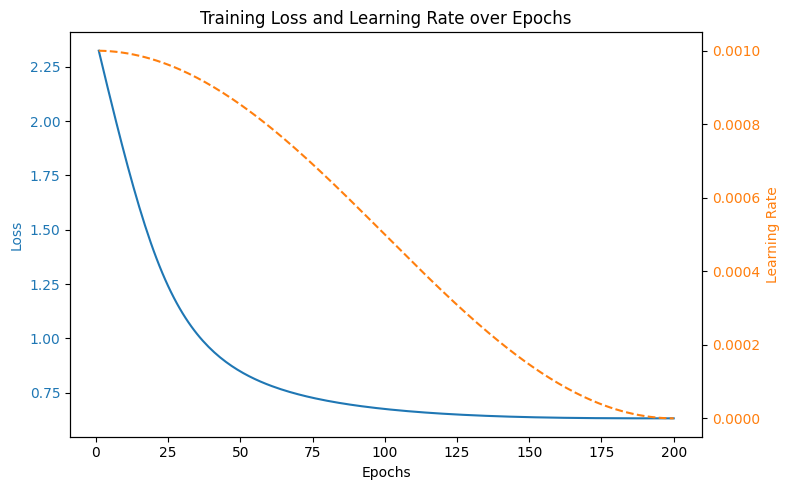

In [44]:
fig, ax1 = plt.subplots(figsize=(8, 5))  # Loss on left y-axis
ax1.plot(
    training_metrics["epochs"], training_metrics["loss"], color="tab:blue", label="Loss"
)
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Loss", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

# Learning rate on right y-axis
ax2 = ax1.twinx()
ax2.plot(
    training_metrics["epochs"],
    training_metrics["learning_rate"],
    color="tab:orange",
    linestyle="--",
    label="Learning Rate",
)
ax2.set_ylabel("Learning Rate", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

ax1.set_title("Training Loss and Learning Rate over Epochs")
fig.tight_layout()
plt.show()

In [ ]:
ecoc_combined_train_pred = ecoc_combined_model.predict_proba(X_unpure_train_full)
ecoc_combined_train_deconv_metrics = compute_deconvolution_metrics(
    ecoc_combined_train_pred, y_unpure_train
)
ecoc_combined_train_deconv_metrics

{'mae': 0.020009389659449952,
 'mse': 0.0016931094875109996,
 'kl': 0.6317384021398053,
 'max_error': 0.7217777371406555,
 'cosine_sim': 0.8953129654973397}

In [ ]:
ecoc_combined_val_pred = ecoc_combined_model.predict_proba(X_unpure_val_full)
ecoc_combined_val_deconv_metrics = compute_deconvolution_metrics(
    ecoc_combined_val_pred, y_unpure_val
)
ecoc_combined_val_deconv_metrics

{'mae': 0.020251164009827287,
 'mse': 0.001843108802662977,
 'kl': 0.6531970384486352,
 'max_error': 0.802376851439476,
 'cosine_sim': 0.8867571185611994}

The MSE is around 1.7e-3, which is better than the MSE we get with any other classification model.

However the model is severely overparameterized, as it has n_bits*39+39 parameters, and only 1000 training samples.

We could obtain better results by using more training samples, which we are going to do in the next section by using the 100000 mixtures with feature selection.

#### 5.3.7 ECOC + binary LS-SVM + Linear layer + Softmax (trained on mixtures with feature selection)

In [47]:
ecoc_combined_model = CombinedECOCCalibrationModel(
    base_estimator=BinaryLSSVM(gamma=1.0, sigma=1.0, kernel="rbf"),
    n_bits=500,
    n_classes=39,
    matrix_construction_mode="full_random",
    random_state=42,
    decision_function_workers=8,
    device="cuda",
)

training_metrics = ecoc_combined_model.fit(
    X_pure=X_pure_ft_selected_by_split["train"],
    y_pure=y_pure_ft_selected.argmax(axis=1),
    X_unpure=X_ft_selected_by_split["train"],
    y_unpure=y_ft_selected,
    n_epochs=50,
    batch_size=5000,
    lr=1e-3,
    return_metrics=True,
)

Fitting ECOC model on pure mixtures...
Finished fitting ECOC model on pure mixtures.
Finished collecting decision values for unpure mixtures.


  0%|          | 0/50 [00:00<?, ?it/s]

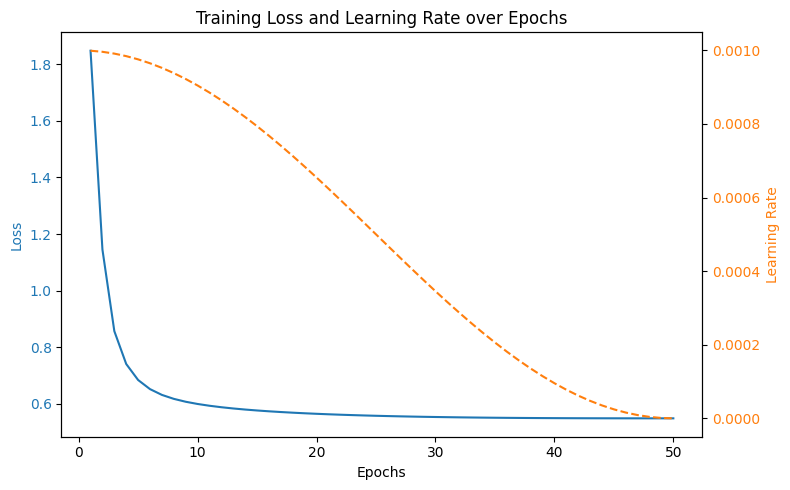

In [48]:
fig, ax1 = plt.subplots(figsize=(8, 5))  # Loss on left y-axis
ax1.plot(
    training_metrics["epochs"], training_metrics["loss"], color="tab:blue", label="Loss"
)
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Loss", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

# Learning rate on right y-axis
ax2 = ax1.twinx()
ax2.plot(
    training_metrics["epochs"],
    training_metrics["learning_rate"],
    color="tab:orange",
    linestyle="--",
    label="Learning Rate",
)
ax2.set_ylabel("Learning Rate", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

ax1.set_title("Training Loss and Learning Rate over Epochs")
fig.tight_layout()
plt.show()

In [ ]:
subset_size = 20000
ecoc_combined_train_pred = ecoc_combined_model.predict_proba(
    X_ft_selected_by_split["train"][:subset_size]
)
ecoc_combined_train_deconv_metrics = compute_deconvolution_metrics(
    ecoc_combined_train_pred, y_ft_selected[:subset_size]
)
ecoc_combined_train_deconv_metrics

{'mae': 0.016939092981675664,
 'mse': 0.0017159195859589498,
 'kl': 0.5505475392750433,
 'max_error': 0.5157008124371957,
 'cosine_sim': 0.9160891485716511}

In [ ]:
subset_size = 20000
ecoc_combined_test_pred = ecoc_combined_model.predict_proba(
    X_ft_selected_by_split["test"][:subset_size]
)
ecoc_combined_test_deconv_metrics = compute_deconvolution_metrics(
    ecoc_combined_test_pred, y_ft_selected[:subset_size]
)
ecoc_combined_test_deconv_metrics

{'mae': 0.017435025690286213,
 'mse': 0.0018694791485900468,
 'kl': 0.5798650810369765,
 'max_error': 0.5854461966078323,
 'cosine_sim': 0.9053097450612475}

The MSE on the train set is again around 1.7e-3, which is not better even though we are using 100x more training samples.

## 6. Modeling with regression models

### 6.1. SVM regression (SVR)

In order to determine how much the lack of performance comes from the fact that SVMs are not designed to predict probabilities, we use Support Vector Regression, which ought to have the same inductive bias as SVMs, and which we also train on the pure mixtures.

#### 6.1.1. Implementation of the SVR

In [51]:
class SimpleMultiTargetSVR(BaseEstimator, RegressorMixin):
    def __init__(
        self,
        kernel="rbf",
        degree=3,
        gamma="scale",
        coef0=0.0,
        tol=1e-3,
        C=1.0,
        epsilon=0.1,
        shrinking=True,
        cache_size=200,
        verbose=False,
        max_iter=-1,
        n_workers=1,
    ):
        self.kernel = kernel
        self.degree = degree
        self.gamma = gamma
        self.coef0 = coef0
        self.tol = tol
        self.C = C
        self.epsilon = epsilon
        self.shrinking = shrinking
        self.cache_size = cache_size
        self.verbose = verbose
        self.max_iter = max_iter
        self.n_workers = n_workers

    def _build_base_estimator(self):
        return SVR(
            kernel=self.kernel,
            degree=self.degree,
            gamma=self.gamma,
            coef0=self.coef0,
            tol=self.tol,
            C=self.C,
            epsilon=self.epsilon,
            shrinking=self.shrinking,
            cache_size=self.cache_size,
            verbose=self.verbose,
            max_iter=self.max_iter,
        )

    def _fit_single_estimator(self, X, y_column):
        estimator = self._build_base_estimator()
        estimator.fit(X, y_column)
        return estimator

    @staticmethod
    def _predict_with_estimator(estimator, X):
        return estimator.predict(X)

    def _fit_estimators_sequential(self, X, y):
        estimators = []
        for output_idx in range(y.shape[1]):
            estimators.append(self._fit_single_estimator(X, y[:, output_idx]))
        return estimators

    def _fit_estimators_parallel(self, X, y):
        with ThreadPoolExecutor(max_workers=self.n_workers) as executor:
            futures = [
                executor.submit(self._fit_single_estimator, X, y[:, output_idx])
                for output_idx in range(y.shape[1])
            ]
            return [future.result() for future in futures]

    def fit(self, X, y):
        X, y = check_X_y(X, y, multi_output=True, y_numeric=True)
        self._y_was_1d_ = y.ndim == 1
        if self._y_was_1d_:
            y = y.reshape(-1, 1)

        if int(self.n_workers) < 1:
            raise ValueError("n_workers must be at least 1")

        if self.n_workers == 1 or y.shape[1] <= 1:
            self.estimators_ = self._fit_estimators_sequential(X, y)
        else:
            self.estimators_ = self._fit_estimators_parallel(X, y)

        self.n_features_in_ = X.shape[1]
        self.n_outputs_ = y.shape[1]
        return self

    def _predict_estimators_sequential(self, X):
        return np.column_stack(
            [
                self._predict_with_estimator(estimator, X)
                for estimator in self.estimators_
            ]
        )

    def _predict_estimators_parallel(self, X):
        with ThreadPoolExecutor(max_workers=self.n_workers) as executor:
            predictions = list(
                executor.map(
                    lambda estimator: self._predict_with_estimator(estimator, X),
                    self.estimators_,
                )
            )
        return np.column_stack(predictions)

    def predict(self, X, normalize_outputs=False):
        """Normalize outputs will clip the predictions to be non-negative, and then normalize them to sum to 1 for each sample."""
        check_is_fitted(self, "estimators_")
        X = check_array(X)

        if self.n_workers == 1 or len(self.estimators_) <= 1:
            preds = self._predict_estimators_sequential(X)
        else:
            preds = self._predict_estimators_parallel(X)

        if normalize_outputs:
            preds = np.clip(preds, a_min=0, a_max=None)
            row_sums = preds.sum(axis=1, keepdims=True)
            preds = np.divide(
                preds, row_sums, where=row_sums != 0, out=np.zeros_like(preds)
            )

        if self._y_was_1d_:
            return preds.ravel()
        return preds

#### 6.1.2. Visualization of the predictions of the SVR on a single sample from the pure mixtures

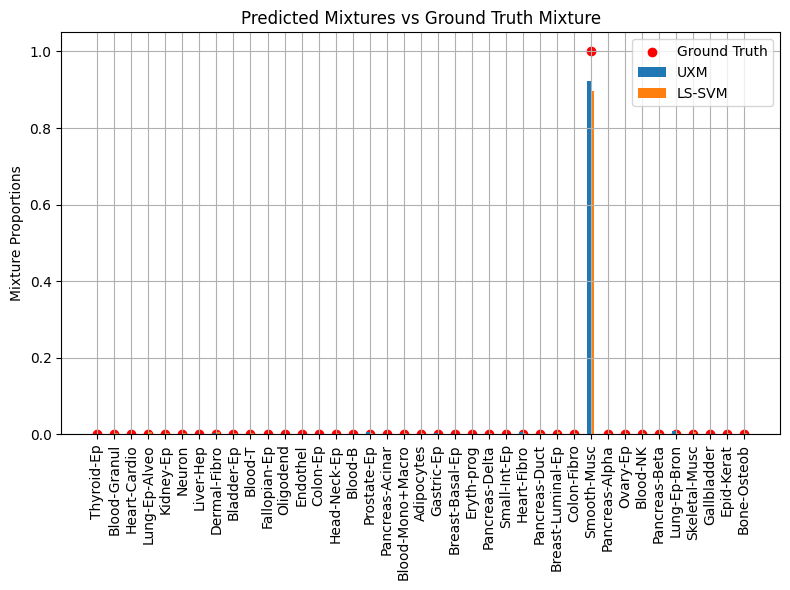

In [52]:
svr = SimpleMultiTargetSVR(kernel="rbf", C=1, epsilon=1e-3)
svr.fit(X_pure_train_full, y_pure_train)
svr_train_pred = svr.predict(X_pure_train_full, normalize_outputs=True)

# visualize the results with one cell type
cell_type = "Smooth-Musc"  # cell type with low separation between the true class score and the second best class score
# cell_type = "Heart-Cardio" # cell type with high separation between the true class score and the second best class score
cell_type_idx = cell_type_to_label[cell_type]

plot_mixtures_pred_vs_true(
    ground_truth_mixture=get_pure_ground_truth_mixture(cell_type_idx),
    predicted_mixtures=[
        get_pure_uxm_results(cell_type_idx, "train"),
        svr_train_pred[cell_type_idx, :],
    ],
    predicted_mixture_labels=["UXM", "LS-SVM"],
)

#### 6.1.3. Evaluation of the SVR on the unpure mixtures

In [ ]:
# Evaluate UXM and SVR on all unpure mixtures (train/val/test) for multiple epsilons and kernels

# User-parameterized epsilon grid (edit as needed)
epsilons_to_test = 10 ** np.linspace(-4, -2, num=9)
additional_epsilons_to_test = [1e-11]
epsilons_to_test = np.sort(
    np.unique(np.concatenate([epsilons_to_test, additional_epsilons_to_test]))
)
kernels_to_test = ["linear", "rbf"]

# Optional SVR hyperparameters
svr_C = 1.0
normalize_outputs = True
svr_n_workers = 8

split_names = ["train", "val", "test"]
n_mixtures = y_unpure_by_split["val"].shape[0]

results = []
svr_models = {}

# UXM baseline per split
uxm_preds_by_split = {
    split_name: np.vstack(
        [
            get_unpure_uxm_results(mixture_idx, split_name)
            for mixture_idx in range(n_mixtures)
        ]
    )
    for split_name in split_names
}

for split_name in split_names:
    uxm_pred = uxm_preds_by_split[split_name]
    uxm_metrics = compute_deconvolution_metrics(uxm_pred, y_unpure_by_split[split_name])
    results.append(
        {
            "model": "UXM",
            "kernel": np.nan,
            "epsilon": np.nan,
            "C": np.nan,
            "split": split_name,
            "label_accuracy": float(
                np.mean(
                    np.argmax(uxm_pred, axis=1)
                    == np.argmax(y_unpure_by_split[split_name], axis=1)
                )
            ),
            **uxm_metrics,
        }
    )

# SVR results per kernel/epsilon
n_loops = len(kernels_to_test) * len(epsilons_to_test) * len(split_names)
with tqdm(total=n_loops, desc="Evaluating SVR models on unpure mixtures") as pbar:
    for kernel in kernels_to_test:
        for epsilon in epsilons_to_test:
            svr = SimpleMultiTargetSVR(
                kernel=kernel,
                C=svr_C,
                epsilon=float(epsilon),
                n_workers=svr_n_workers,
            )
            svr.fit(X_pure_train_full, y_pure_train)
            svr_models[(kernel, float(epsilon))] = svr

            for split_name in split_names:
                y_pred = svr.predict(
                    X_unpure_full_by_split[split_name],
                    normalize_outputs=normalize_outputs,
                )
                svr_metrics = compute_deconvolution_metrics(
                    y_pred, y_unpure_by_split[split_name]
                )
                results.append(
                    {
                        "model": "SVR",
                        "kernel": kernel,
                        "epsilon": float(epsilon),
                        "C": svr_C,
                        "split": split_name,
                        "label_accuracy": float(
                            np.mean(
                                np.argmax(y_pred, axis=1)
                                == np.argmax(y_unpure_by_split[split_name], axis=1)
                            )
                        ),
                        **svr_metrics,
                    }
                )
                pbar.update(1)

unpure_svr_metrics_df = pd.DataFrame(results).sort_values(["split", "model", "mse"])
display(unpure_svr_metrics_df)

Evaluating SVR models on unpure mixtures:   0%|          | 0/60 [00:00<?, ?it/s]

,model,kernel,epsilon,C,split,label_accuracy,mae,mse,kl,max_error,cosine_sim
35,SVR,rbf,1.000000e-11,1.0,test,0.718,0.010398,0.000841,0.366853,0.535030,0.936956
38,SVR,rbf,1.000000e-04,1.0,test,0.719,0.010423,0.000842,0.367528,0.535216,0.936877
41,SVR,rbf,1.778279e-04,1.0,test,0.718,0.010454,0.000844,0.368324,0.535721,0.936774
44,SVR,rbf,3.162278e-04,1.0,test,0.719,0.010492,0.000846,0.369179,0.538235,0.936676
47,SVR,rbf,5.623413e-04,1.0,test,0.720,0.010576,0.000849,0.371506,0.540859,0.936473
...,...,...,...,...,...,...,...,...,...,...,...
4,SVR,linear,1.000000e-11,1.0,val,0.529,0.011490,0.001491,0.310973,0.883346,0.902286
25,SVR,linear,3.162278e-03,1.0,val,0.529,0.013872,0.001503,0.402804,0.904457,0.903384
28,SVR,linear,5.623413e-03,1.0,val,0.529,0.016636,0.001756,0.514573,0.919626,0.901241
31,SVR,linear,1.000000e-02,1.0,val,0.529,0.021184,0.002409,0.675564,0.935528,0.890954


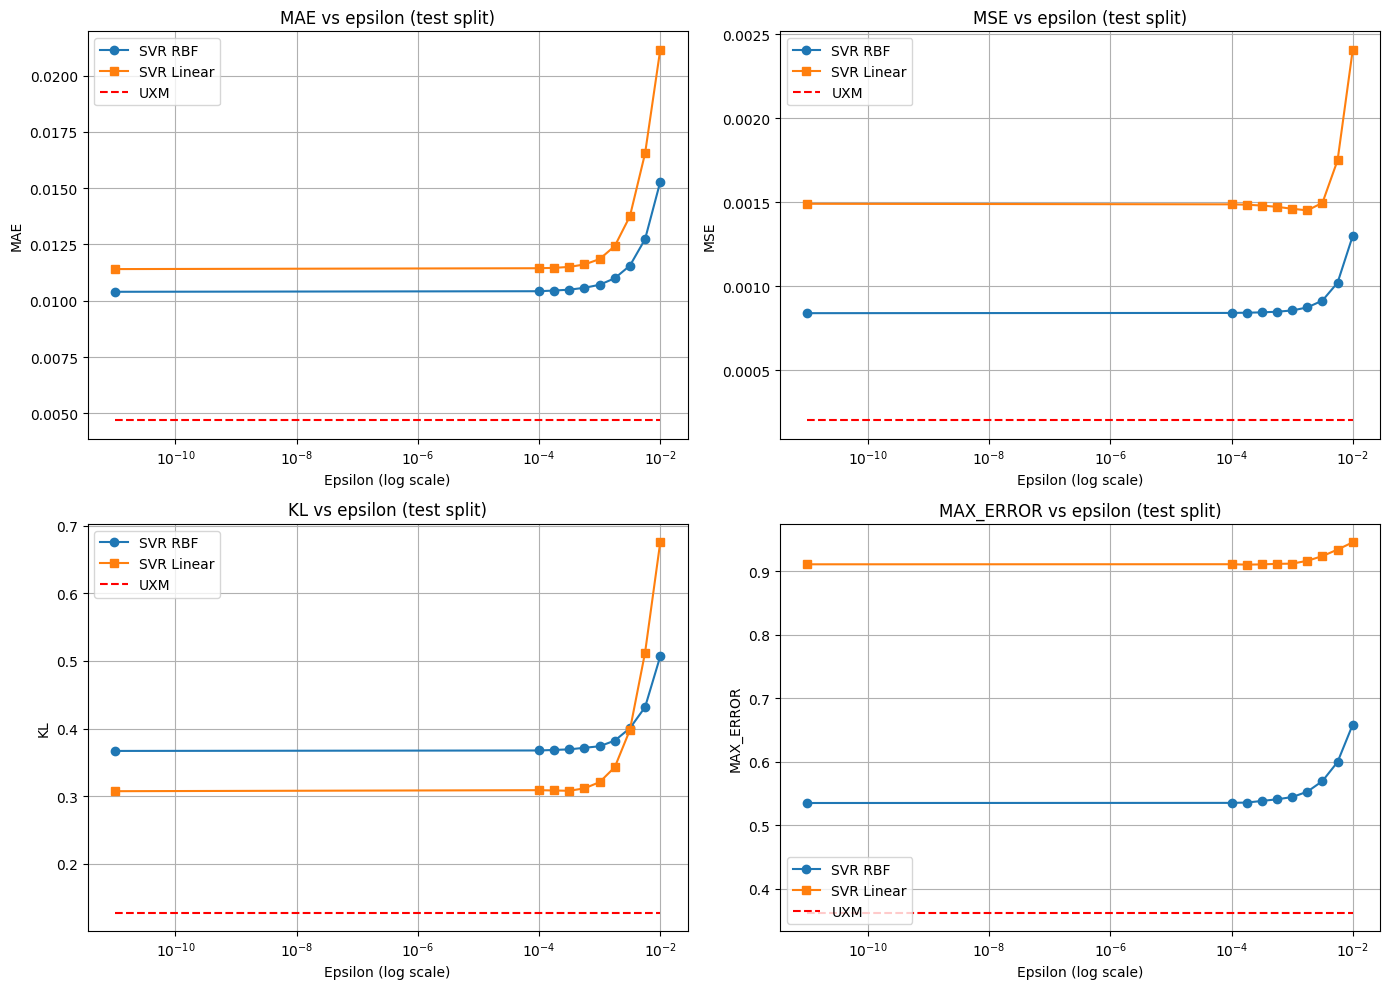

In [54]:
split = "test"
rbf_metrics = unpure_svr_metrics_df[
    (unpure_svr_metrics_df["model"] == "SVR")
    & (unpure_svr_metrics_df["kernel"] == "rbf")
    & (unpure_svr_metrics_df["split"] == split)
].sort_values("epsilon")

linear_metrics = unpure_svr_metrics_df[
    (unpure_svr_metrics_df["model"] == "SVR")
    & (unpure_svr_metrics_df["kernel"] == "linear")
    & (unpure_svr_metrics_df["split"] == split)
].sort_values("epsilon")

uxm_metrics = unpure_svr_metrics_df[
    (unpure_svr_metrics_df["model"] == "UXM")
    & (unpure_svr_metrics_df["split"] == split)
]

# best_svm_row = unpure_metrics_df[
#     (unpure_metrics_df["model"] == "LS-SVM")
#     & (unpure_metrics_df["split"] == split)
# ].sort_values("mse").iloc[0]


metrics_to_plot = ["mae", "mse", "kl", "max_error"]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

epsilon_min = min(rbf_metrics["epsilon"].min(), linear_metrics["epsilon"].min())
epsilon_max = max(rbf_metrics["epsilon"].max(), linear_metrics["epsilon"].max())

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx]
    ax.plot(rbf_metrics["epsilon"], rbf_metrics[metric], marker="o", label="SVR RBF")
    ax.plot(
        linear_metrics["epsilon"],
        linear_metrics[metric],
        marker="s",
        label="SVR Linear",
    )
    ax.hlines(
        y=uxm_metrics[metric].iloc[0],
        xmin=epsilon_min,
        xmax=epsilon_max,
        colors="red",
        linestyles="dashed",
        label="UXM",
    )
    ax.set_xscale("log")
    ax.set_xlabel("Epsilon (log scale)")
    ax.set_ylabel(metric.upper())
    ax.set_title(f"{metric.upper()} vs epsilon ({split} split)")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

Observations:
- the performance of the SVR is not good, but it is much better than the performance of the SVMs, which suggests that the issue with the SVMs is indeed that they are not designed to predict probabilities, and that the scores they produce are not well calibrated.
- the performance of the SVR saturates at around eps=1e-4, which is probably because around this epsilon, the training samples are already all outside of the epsilon tube, and thus picked as support vectors, and increasing epsilon further does not change the model anymore. 

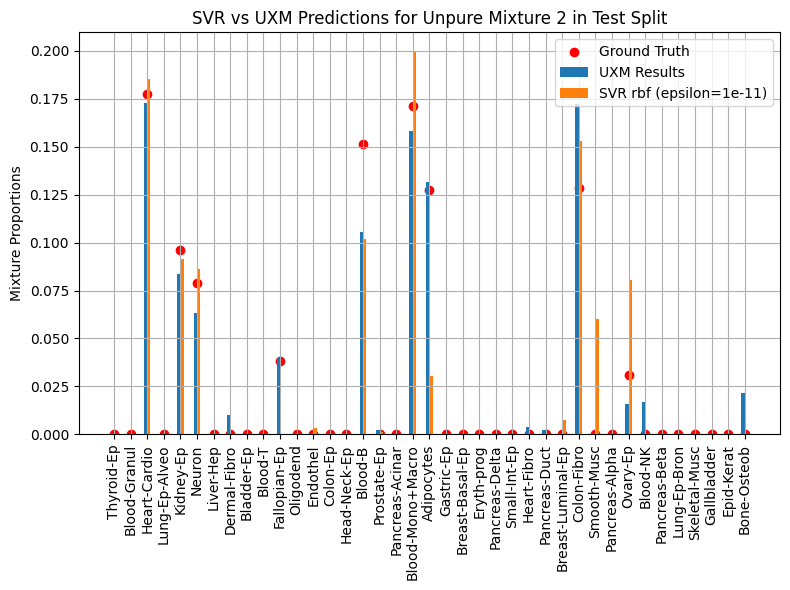

In [55]:
# select the SVR with best mse and plot its predictions against the ground truth for one of the unpure mixtures in the validation set
best_svr_row = (
    unpure_svr_metrics_df[
        (unpure_svr_metrics_df["model"] == "SVR")
        & (unpure_svr_metrics_df["split"] == "test")
    ]
    .sort_values("mse")
    .iloc[0]
)
best_svr_model = svr_models[(best_svr_row["kernel"], best_svr_row["epsilon"])]

unpure_mixture_idx = 2
svr_unpure_pred = best_svr_model.predict(
    X_unpure_train_full[unpure_mixture_idx].reshape(1, -1),
    normalize_outputs=True,
).squeeze()
ground_truth_unpure_mixture = get_unpure_ground_truth_mixture(unpure_mixture_idx)
plot_mixtures_pred_vs_true(
    ground_truth_mixture=ground_truth_unpure_mixture,
    predicted_mixtures=[
        get_unpure_uxm_results(unpure_mixture_idx, "train"),
        svr_unpure_pred,
    ],
    predicted_mixture_labels=[
        "UXM Results",
        f"SVR {best_svr_row['kernel']} (epsilon={best_svr_row['epsilon']:.3g})",
    ],
    title=f"SVR vs UXM Predictions for Unpure Mixture {unpure_mixture_idx} in Test Split",
)